# Mortgage and corporate PD distributions — obligor counts, June 2026

**Run all cells to create the charts.** This notebook contains its own EBA CR6
data snapshot (3 October 2026) and plots it with Matplotlib. No companion data
files, scripts or chart files are needed. Charts are generated as standard PNG
notebook outputs. Missing Python packages are installed by the first code cell.

The selection is up to **10 group-level reporters per country** in **France,
the Netherlands, Germany, Denmark, Sweden and Poland**. Only filings marked
**highest EEA level** are included; subsidiary reporters are excluded. The saved
snapshot contains no eligible Polish group-level filings.

Banks are ranked by combined reported mortgage and corporate EAD subtotals at
each bank's latest available date, requiring complete, positive totals in a
consistent currency. Reporting dates and unstandardized reporting scales can
affect rankings. Only available **obligor-count distributions for 30 June 2026**
are plotted for the selected groups. Banking groups and countries without any
matching distributions are omitted. This is the embedded snapshot, not a live
data refresh.

Mortgages are retail exposures secured by residential real estate. Corporates
includes other, specialised lending and purchased receivables, with IRB
approaches kept separate. Charts show shares of non-defaulted totals in seven
categorical PD bands; missing or invalid distributions are omitted.


In [1]:
import importlib.util
import subprocess
import sys

missing = [name for name in ["numpy", "pandas", "matplotlib"]
           if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import base64
import json
import textwrap
import zlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

%matplotlib inline
set_matplotlib_formats("png")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white"})


In [2]:
# Embedded source values and validation statuses; no external files are read.
# Only highest-EEA filings for mortgages/corporates in the requested countries.
SNAPSHOT_B64 = (
    '...'
)
snapshot = json.loads(zlib.decompress(base64.b64decode(SNAPSHOT_B64)).decode("utf-8"))
records = pd.DataFrame(snapshot["records"])
BANDS = snapshot["bands"]


In [3]:
COUNTRIES = ["France", "Netherlands", "Germany", "Denmark", "Sweden", "Poland"]
TOP_N = 10
REFERENCE_DATE = "2026-06-30"

# Apply the group-level restriction before ranking, and retain only those filings.
records = records.loc[
    records.country.isin(COUNTRIES) & records.is_highest_eea.eq("YES")
].copy()
ead = records.loc[records.metric.eq("ead")]
latest = ead.loc[ead.reference_date.eq(ead.groupby("lei").reference_date.transform("max"))]
ranking = latest.groupby(["country", "lei", "bank", "reference_date"], as_index=False).agg(
    exposure=("reported_total", lambda values: values.sum(min_count=1)),
    complete=("reported_total", lambda values: values.notna().all()),
    currency=("currency", "first"),
    currencies=("currency", "nunique"),
)
eligible = ranking.loc[
    ranking.complete & ranking.exposure.gt(0)
    & ranking.currencies.eq(1) & ranking.currency.ne("unspecified")
].copy()
if eligible.groupby("country").currency.nunique().gt(1).any():
    raise ValueError("Ranking requires a consistent currency within each country.")
selected = (
    eligible.sort_values(["country", "exposure", "lei"], ascending=[True, False, True])
    .groupby("country", sort=False).head(TOP_N).copy()
)
selected["rank"] = selected.groupby("country").cumcount() + 1
# Restrict the charts to available obligor counts at the requested date.
distributions = records.loc[
    records.lei.isin(selected.lei)
    & records.reference_date.eq(REFERENCE_DATE)
    & records.metric.eq("obligors")
    & records.status.eq("ready")
].copy()
selected = selected.loc[selected.lei.isin(distributions.lei)].copy()


**23 banking groups · 79 obligor-count distributions · June 2026.**

## France — 3 groups

### 1. BNP Paribas
LEI: R0MUWSFPU8MPRO8K5P83 · Ranking date: 2026-06-30

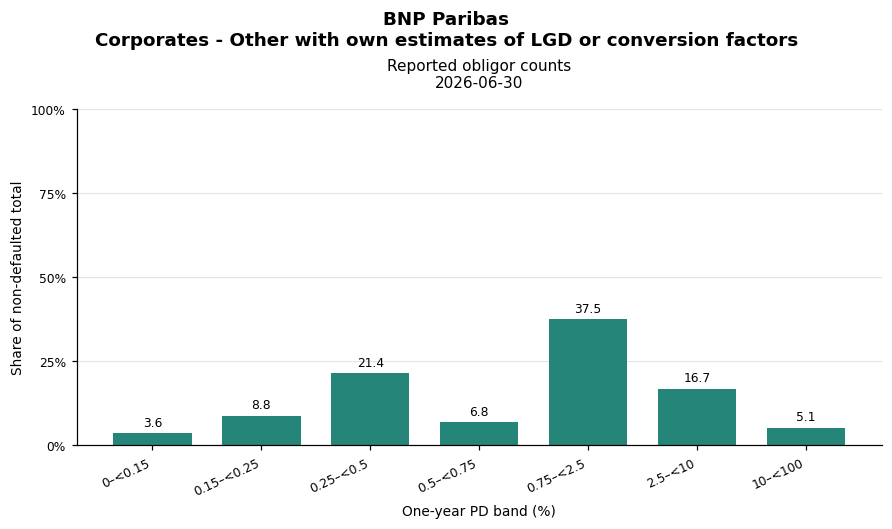

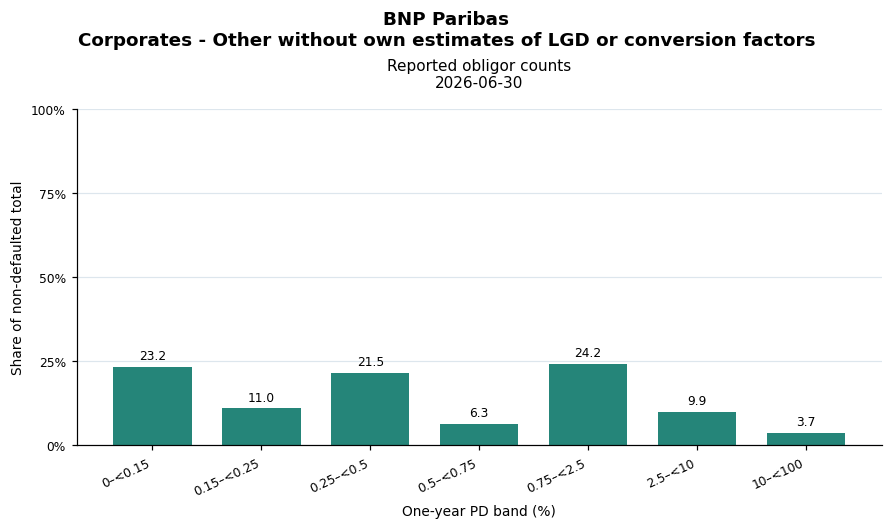

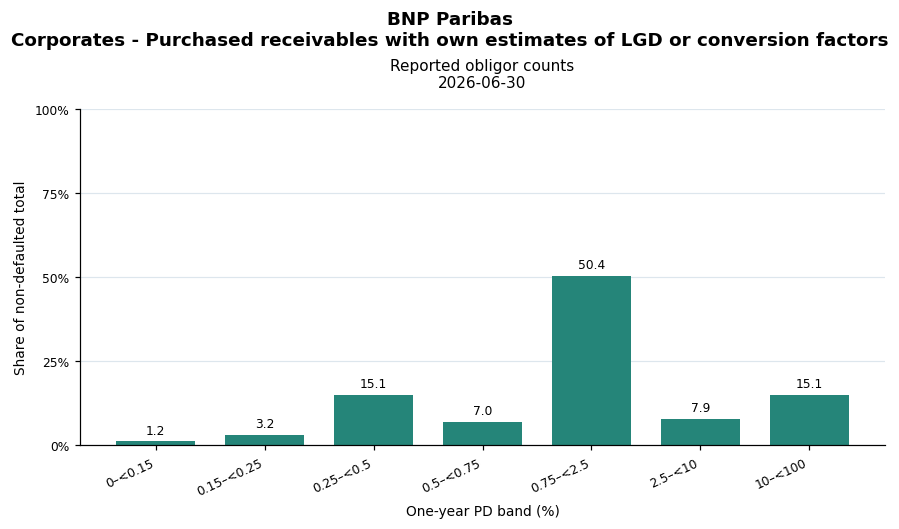

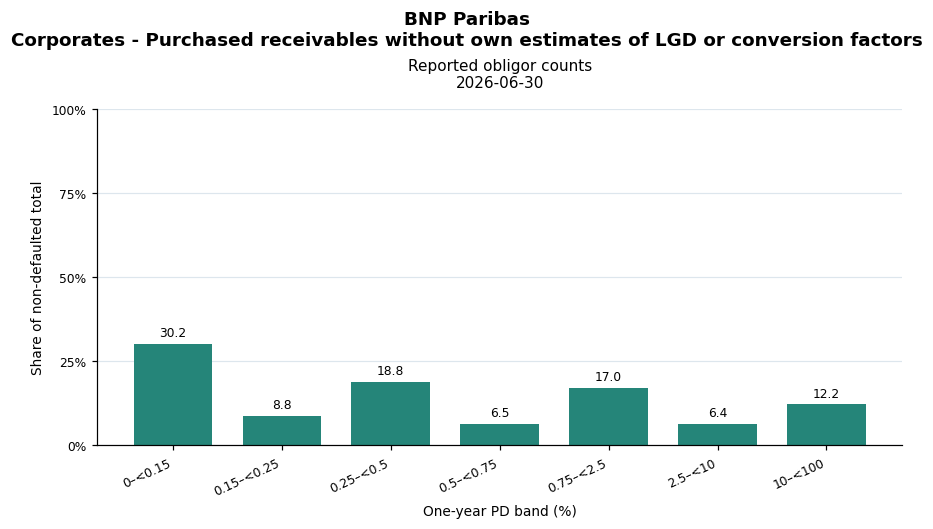

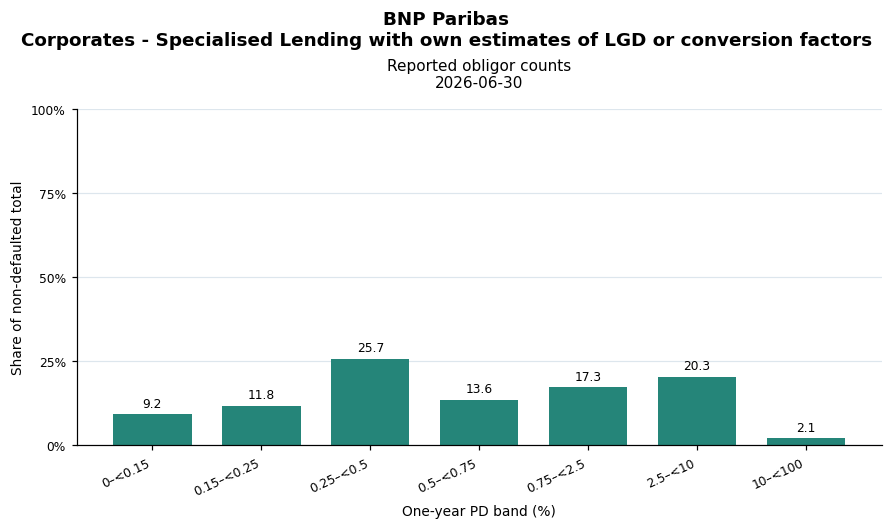

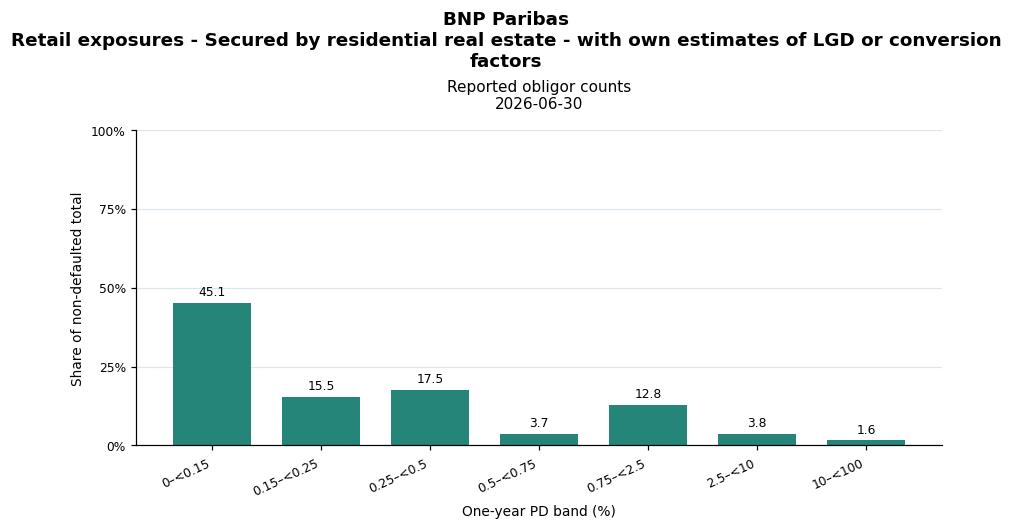

### 2. Groupe BPCE
LEI: FR9695005MSX1OYEMGDF · Ranking date: 2026-06-30

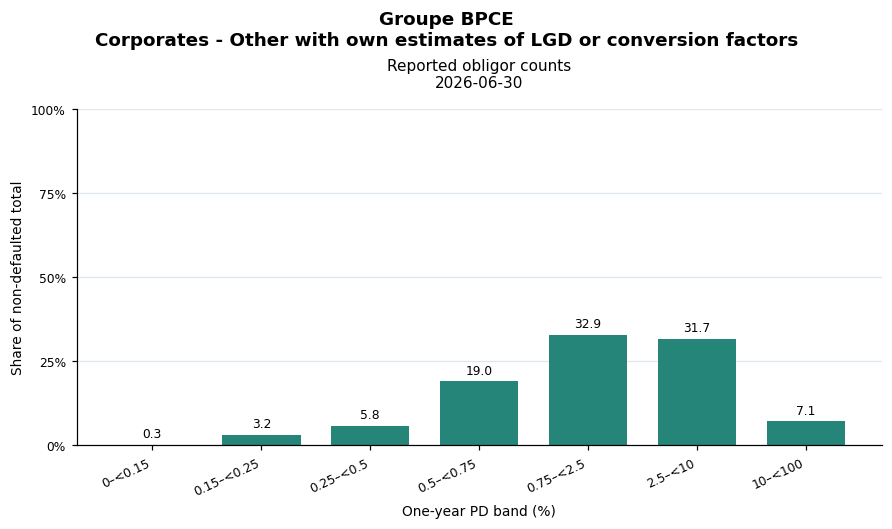

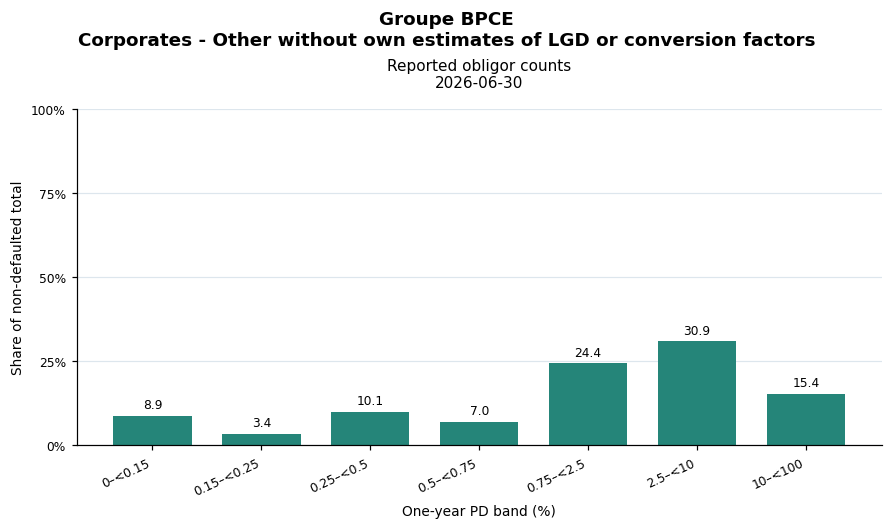

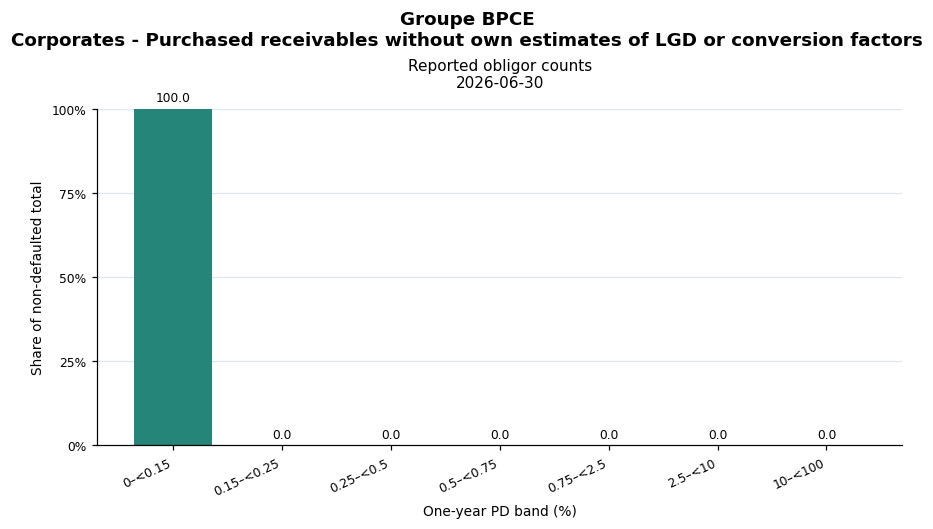

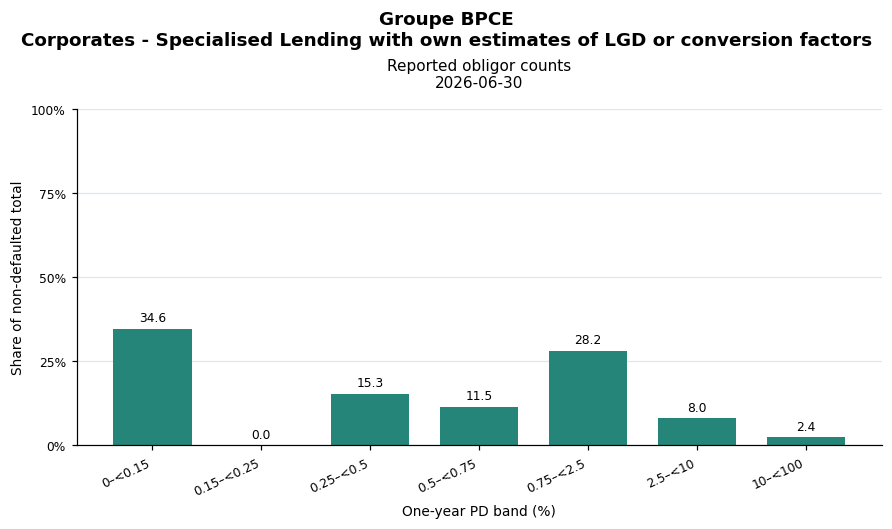

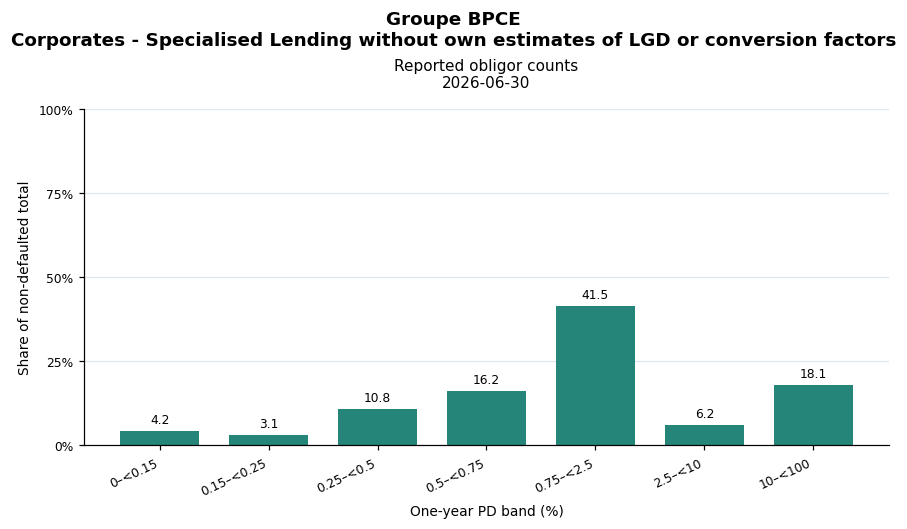

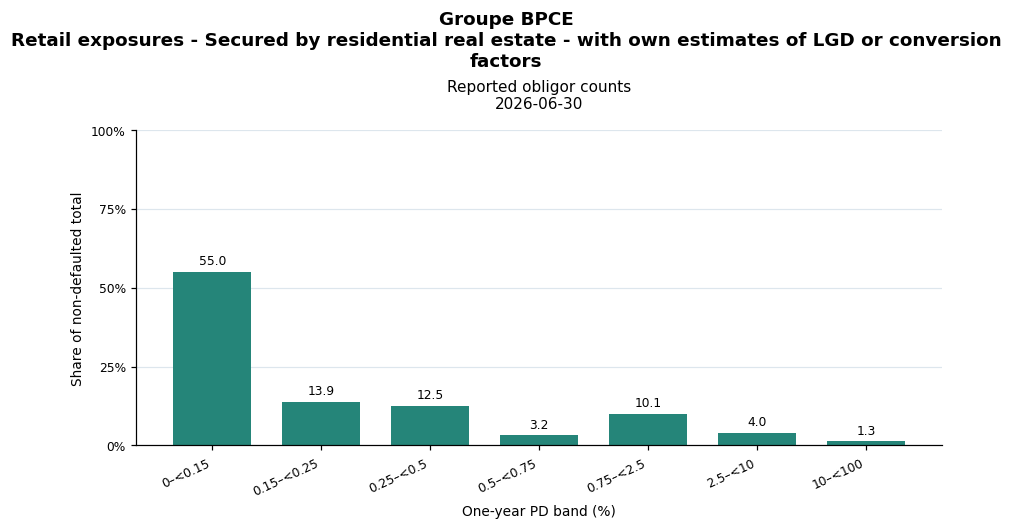

### 4. Société générale S.A.
LEI: O2RNE8IBXP4R0TD8PU41 · Ranking date: 2026-06-30

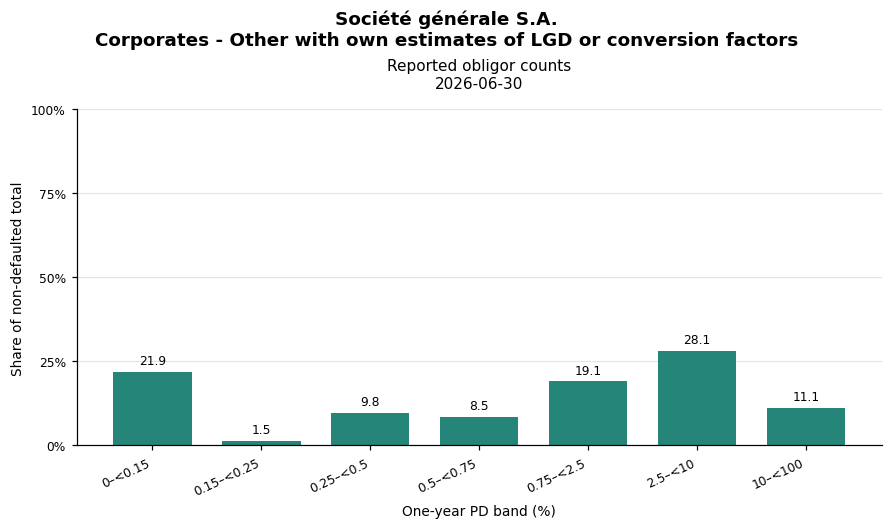

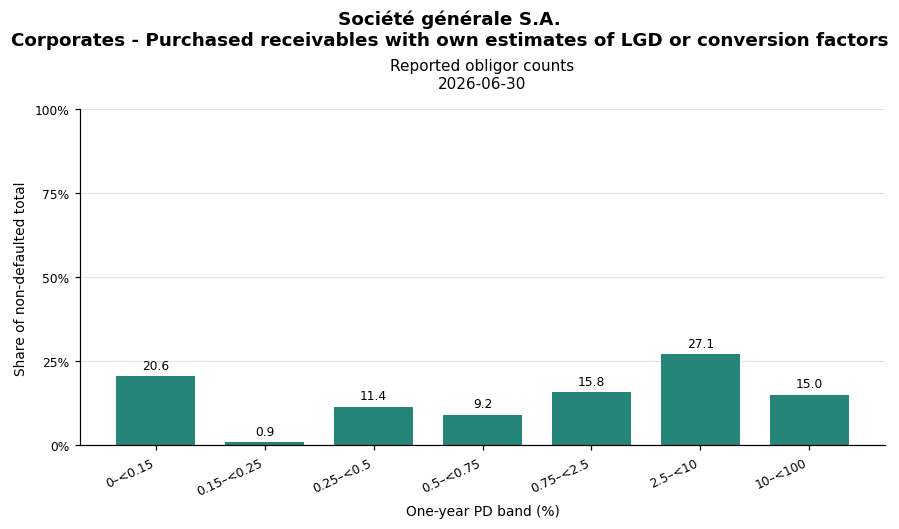

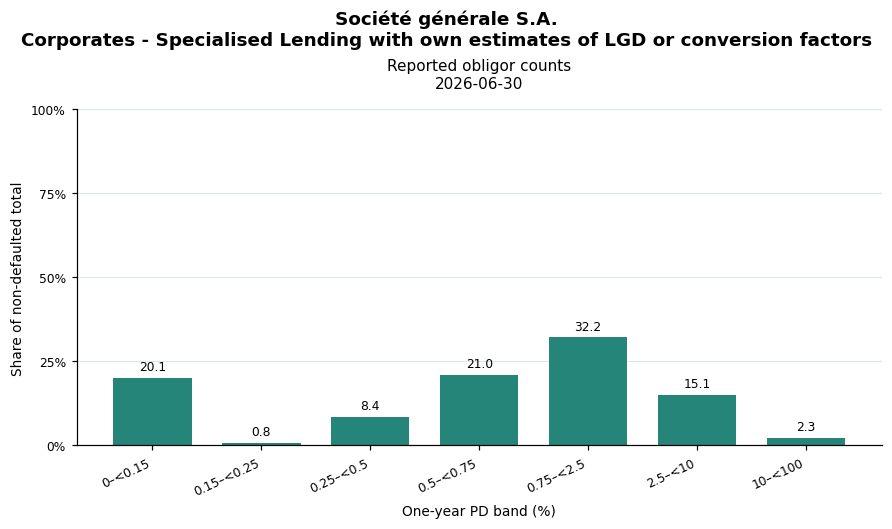

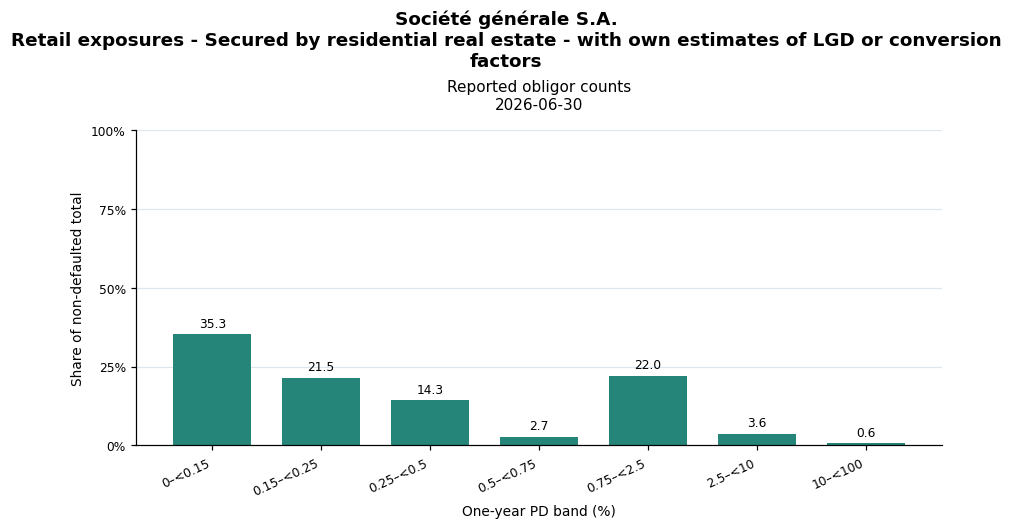

## Netherlands — 4 groups

### 1. ING Groep N.V.
LEI: 549300NYKK9MWM7GGW15 · Ranking date: 2026-06-30

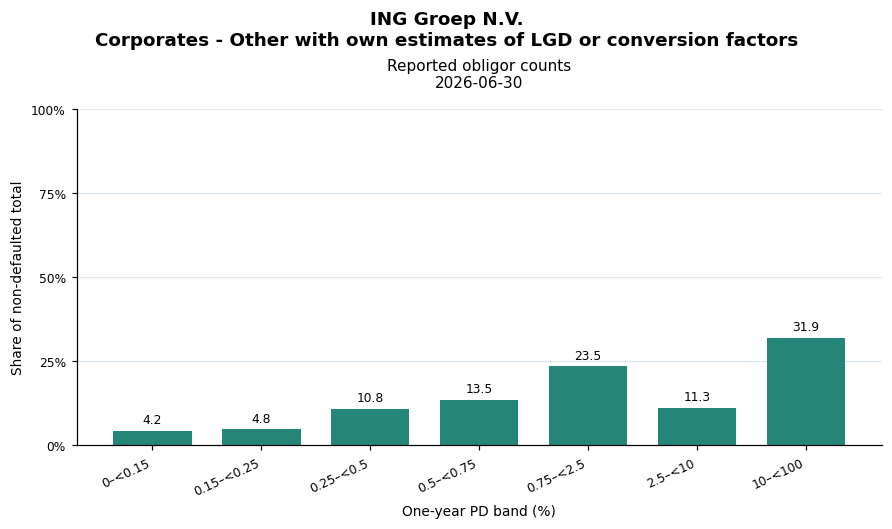

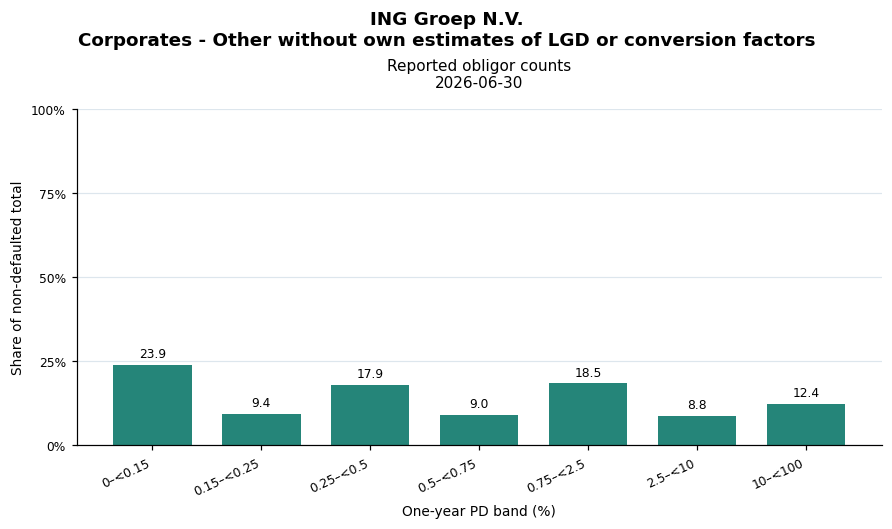

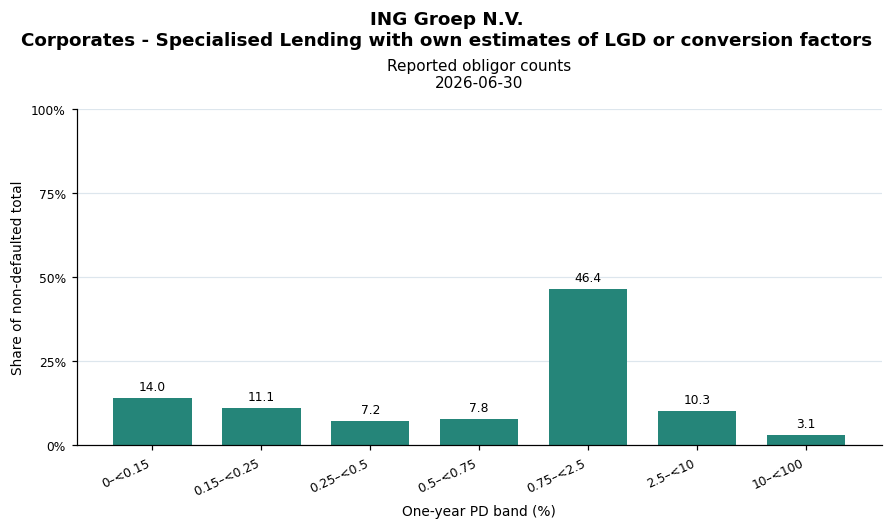

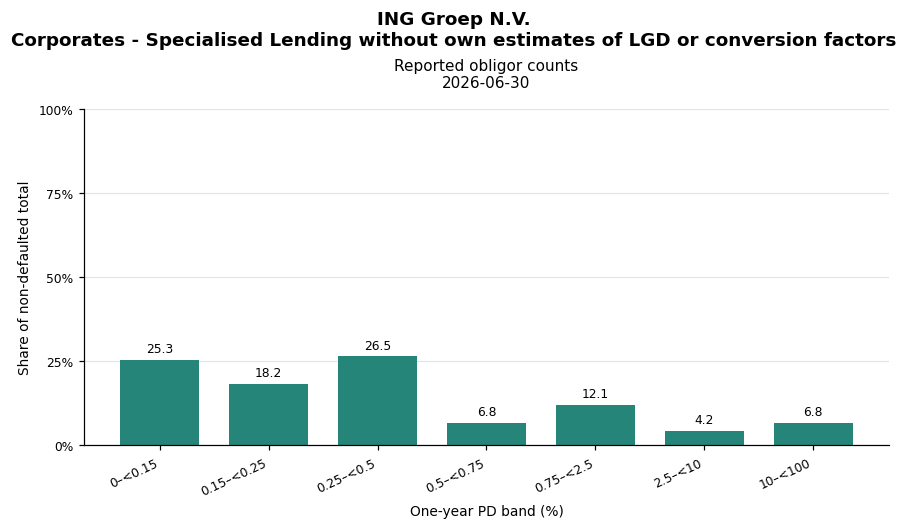

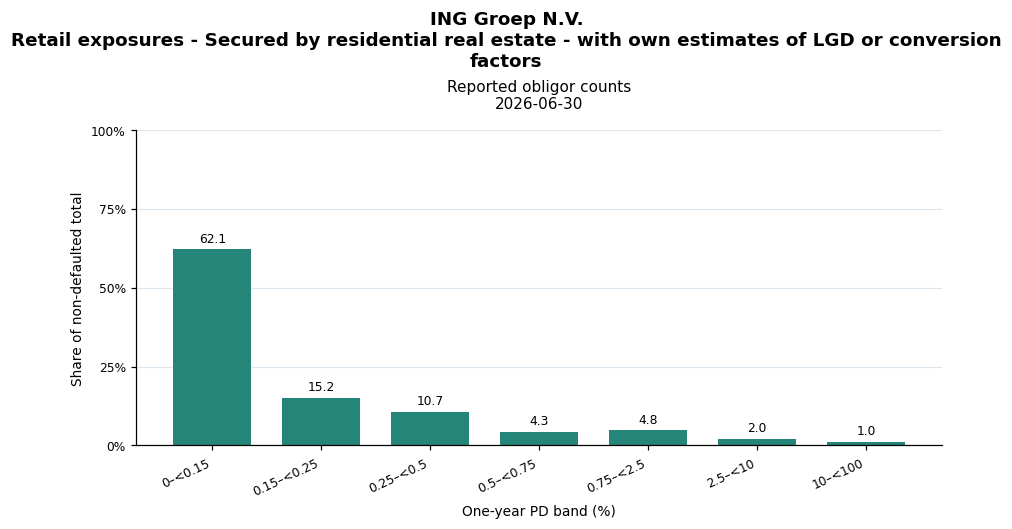

### 2. Coöperatieve Rabobank U.A.
LEI: DG3RU1DBUFHT4ZF9WN62 · Ranking date: 2026-06-30

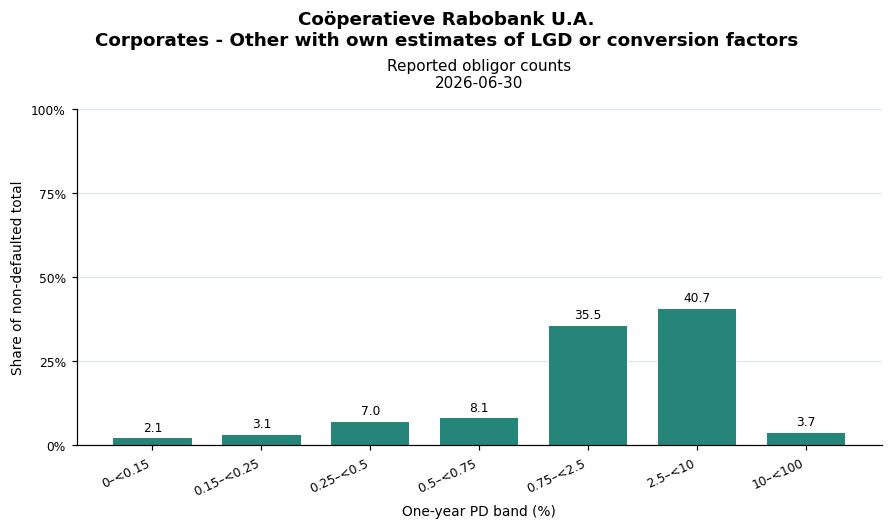

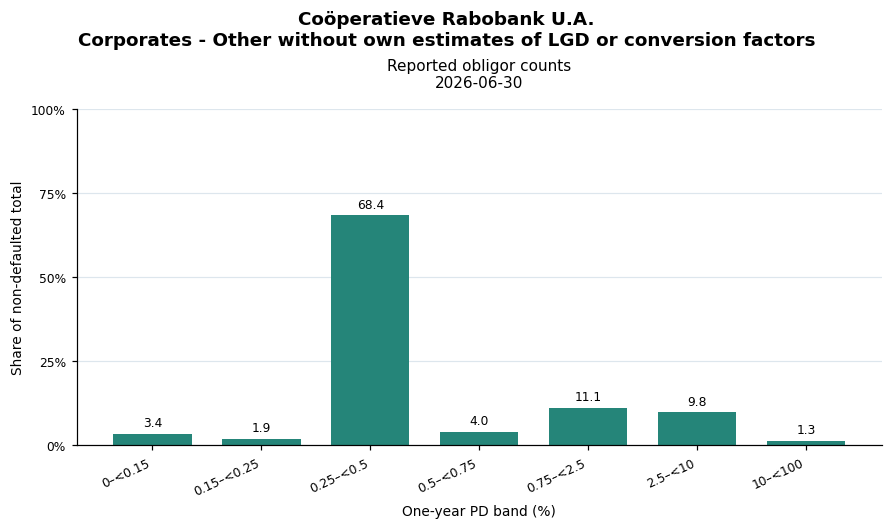

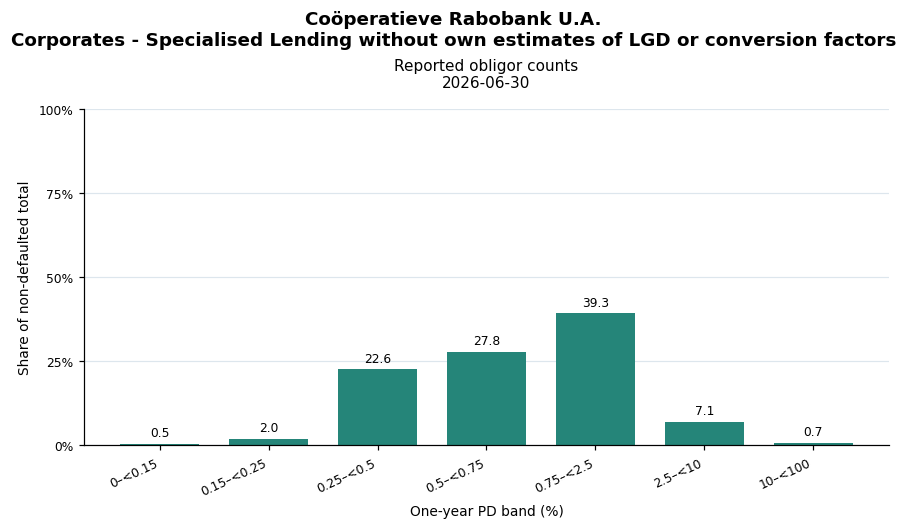

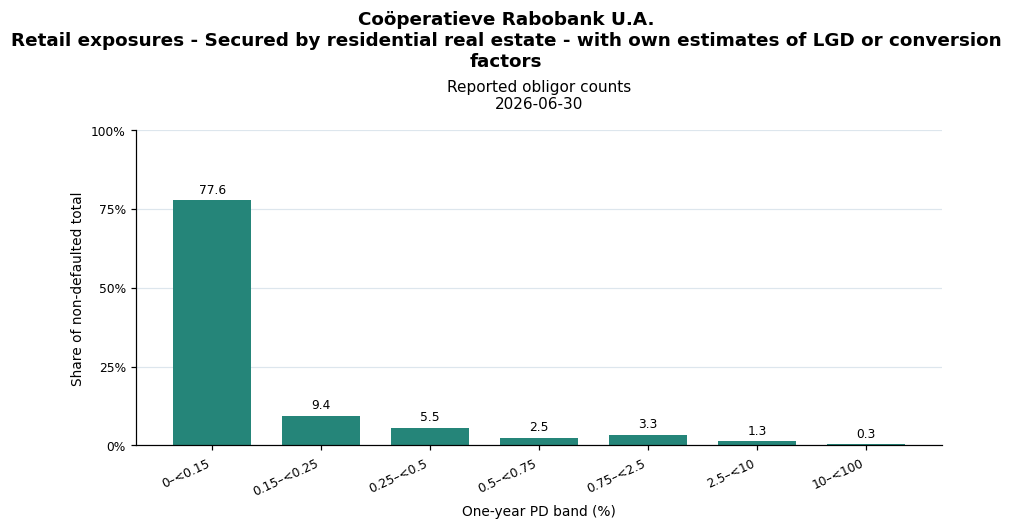

### 3. ABN AMRO Bank N.V.
LEI: BFXS5XCH7N0Y05NIXW11 · Ranking date: 2026-06-30

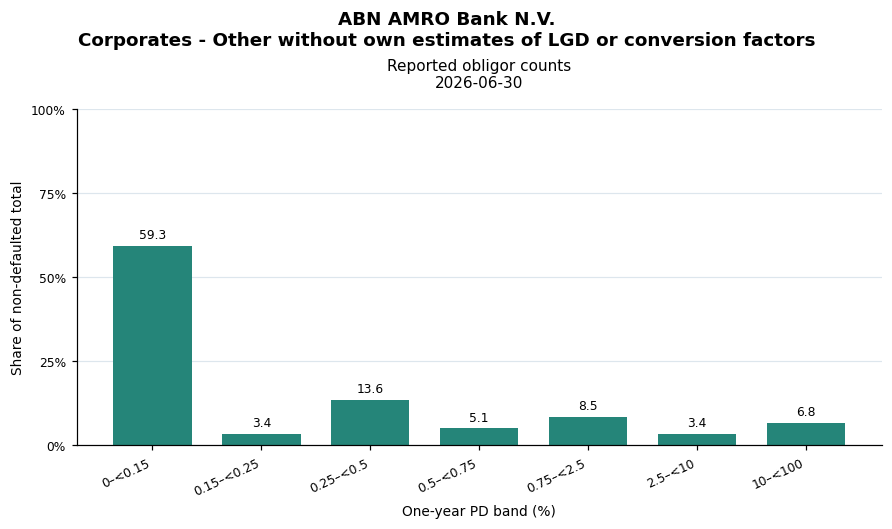

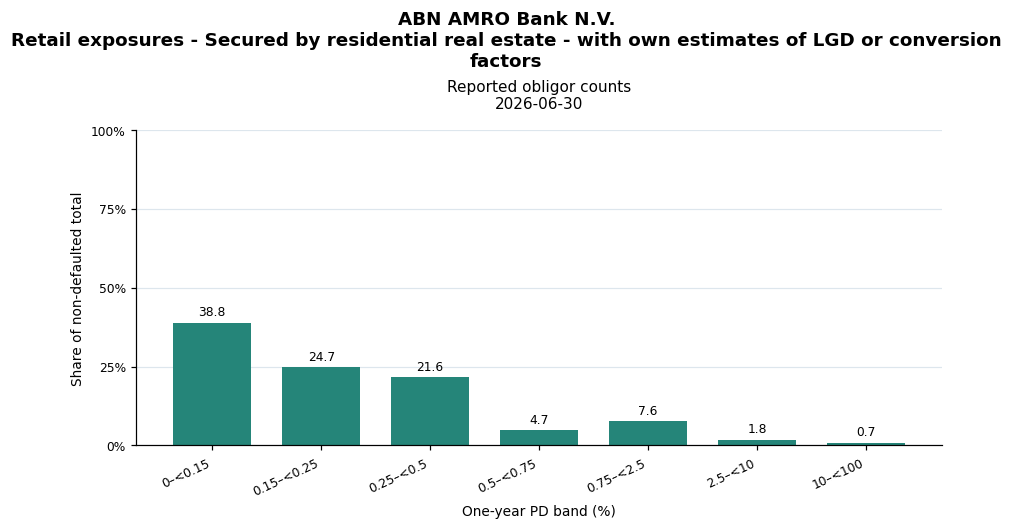

### 4. ASN Bank N.V.
LEI: 724500A1FNICHSDF2I11 · Ranking date: 2026-06-30

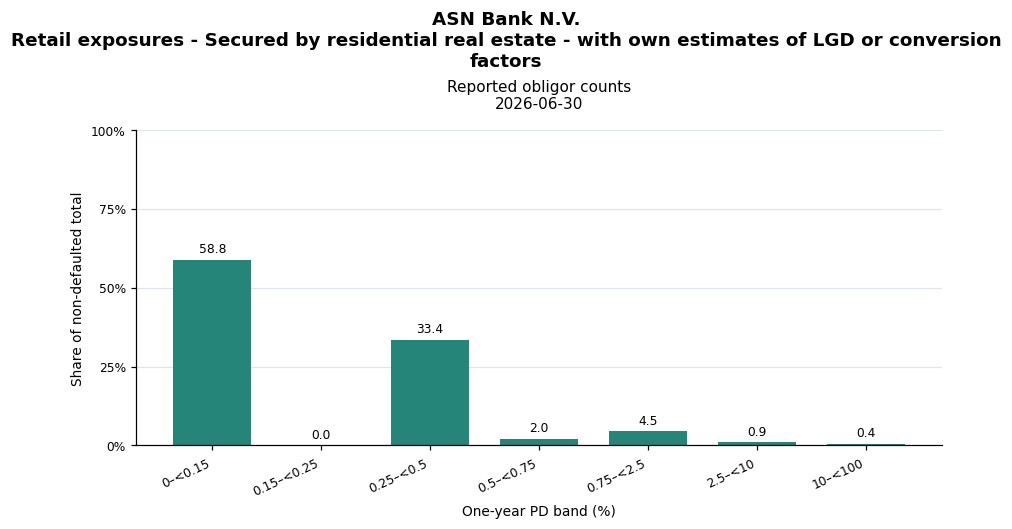

## Germany — 8 groups

### 1. DEUTSCHE BANK AKTIENGESELLSCHAFT
LEI: 7LTWFZYICNSX8D621K86 · Ranking date: 2026-06-30

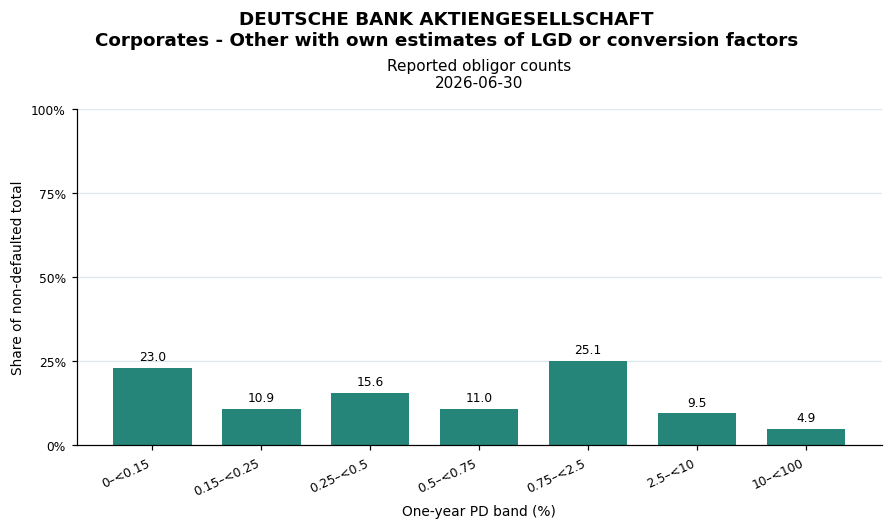

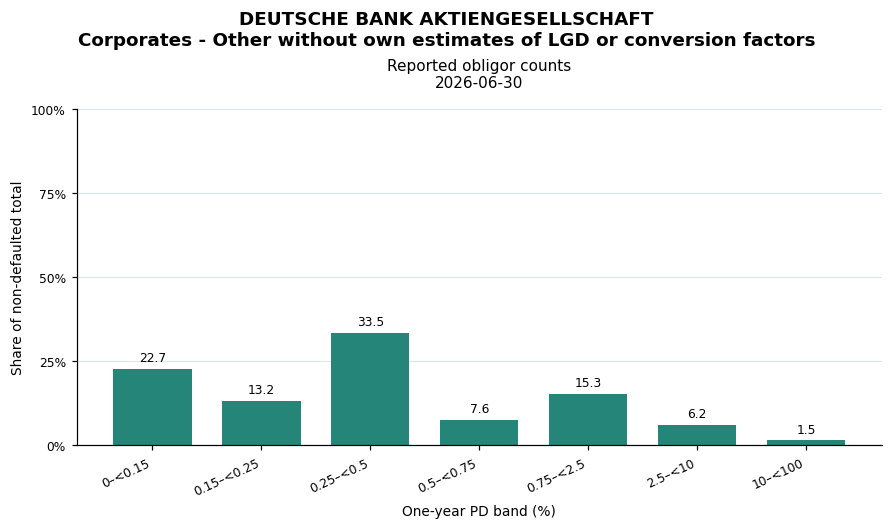

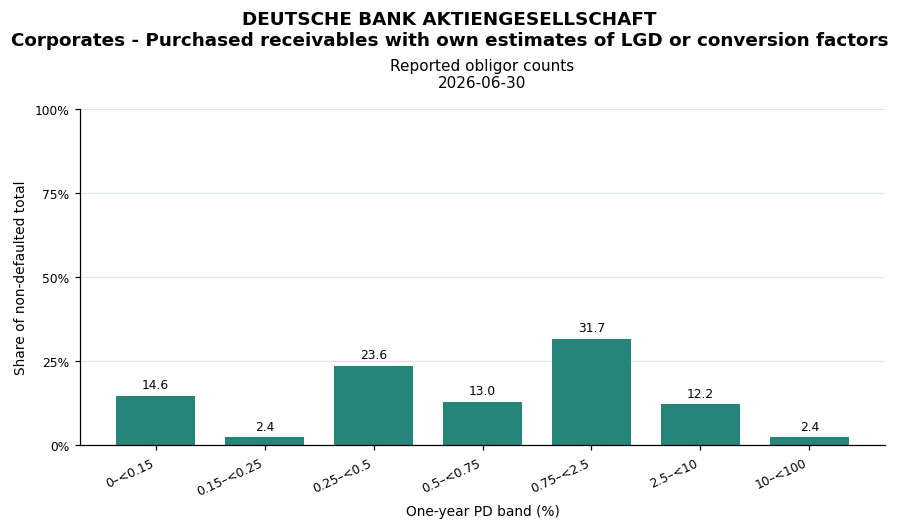

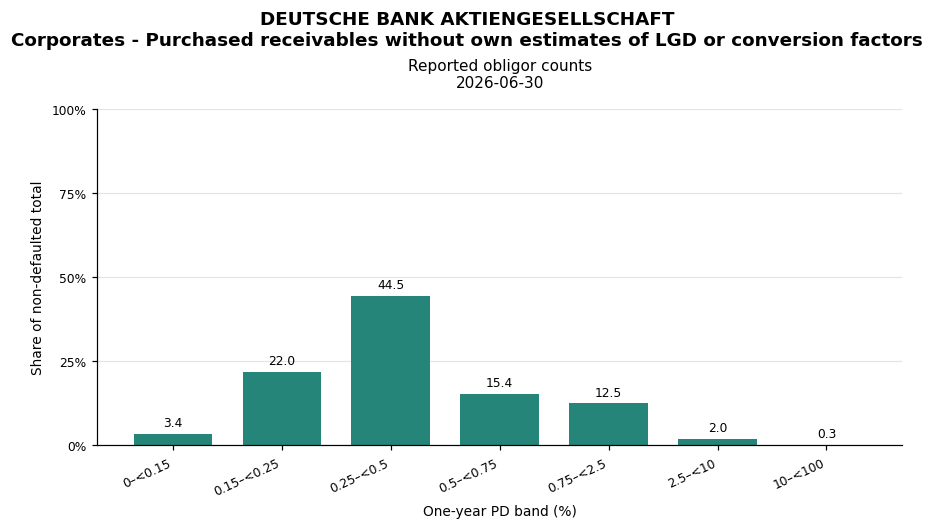

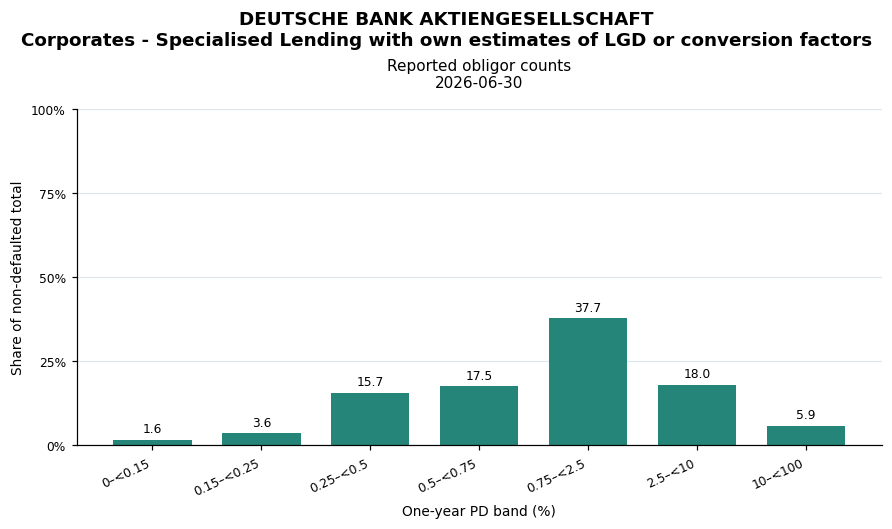

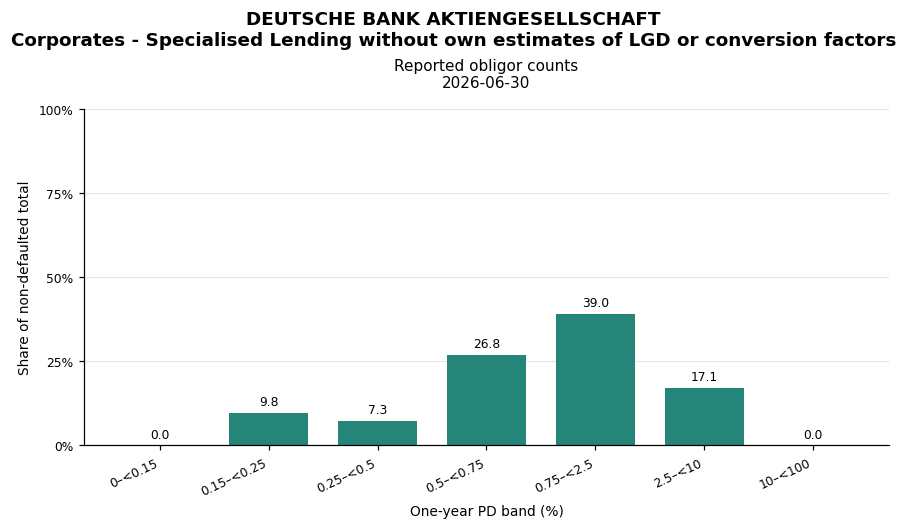

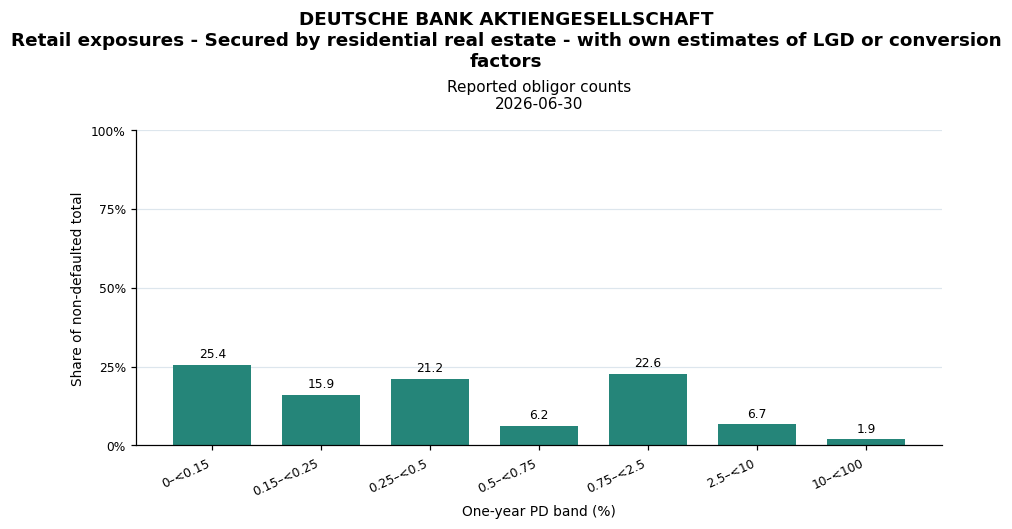

### 2. COMMERZBANK Aktiengesellschaft
LEI: 851WYGNLUQLFZBSYGB56 · Ranking date: 2026-06-30

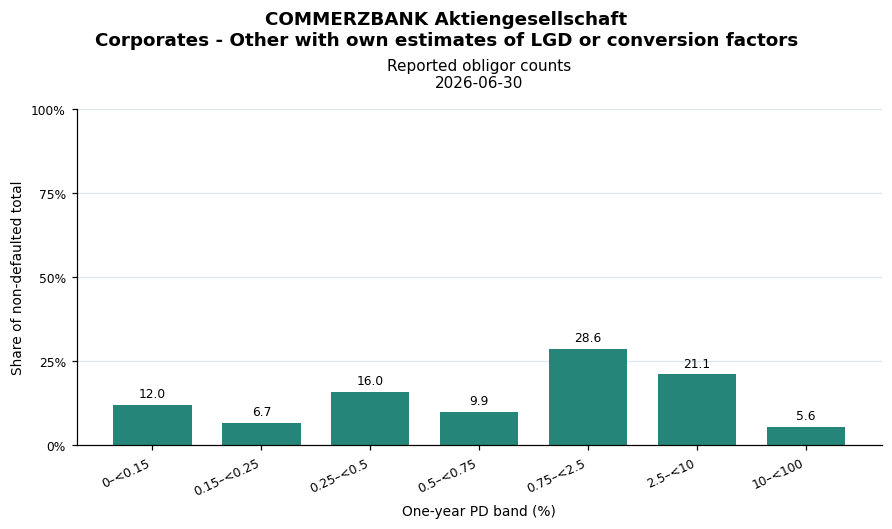

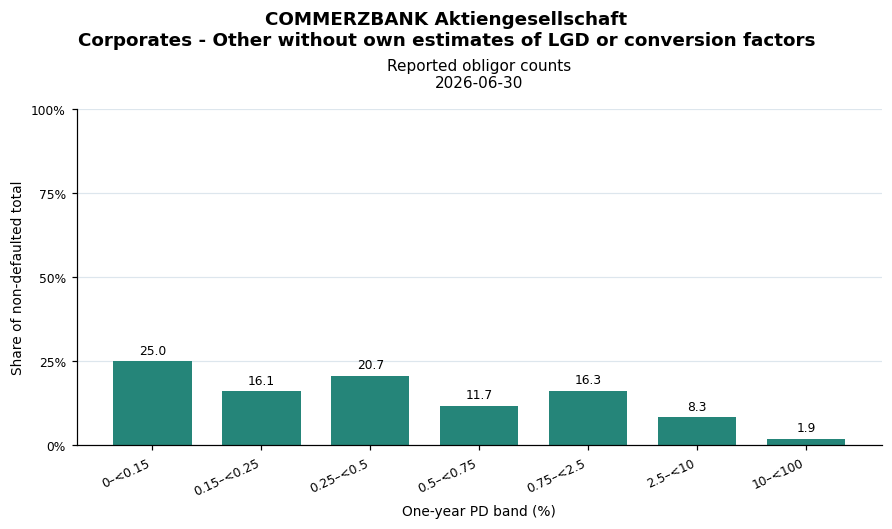

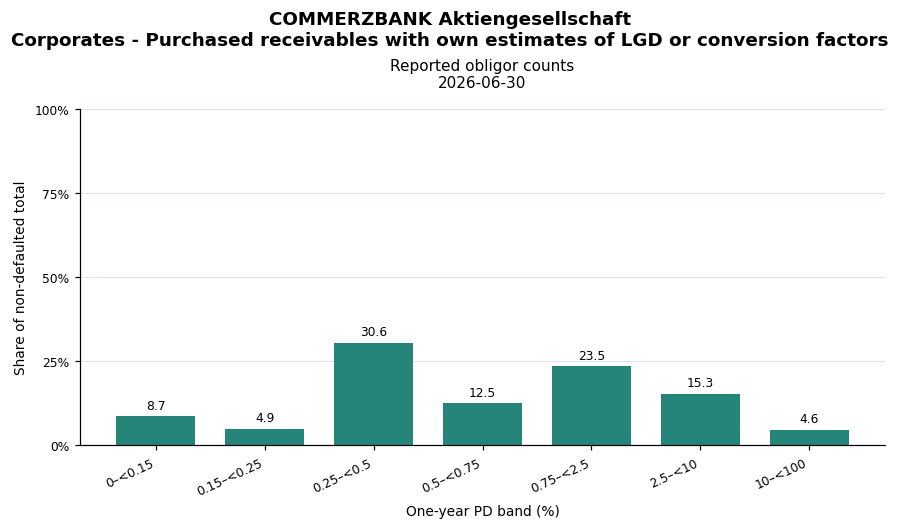

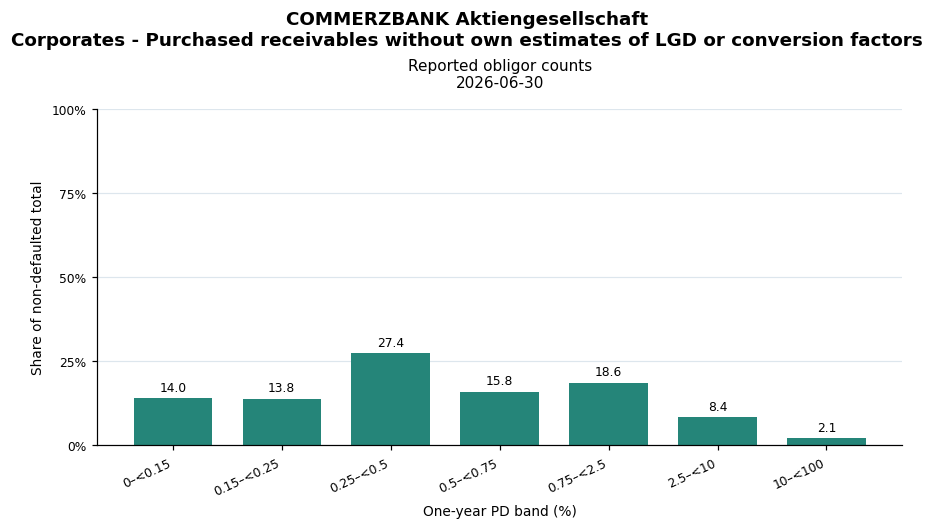

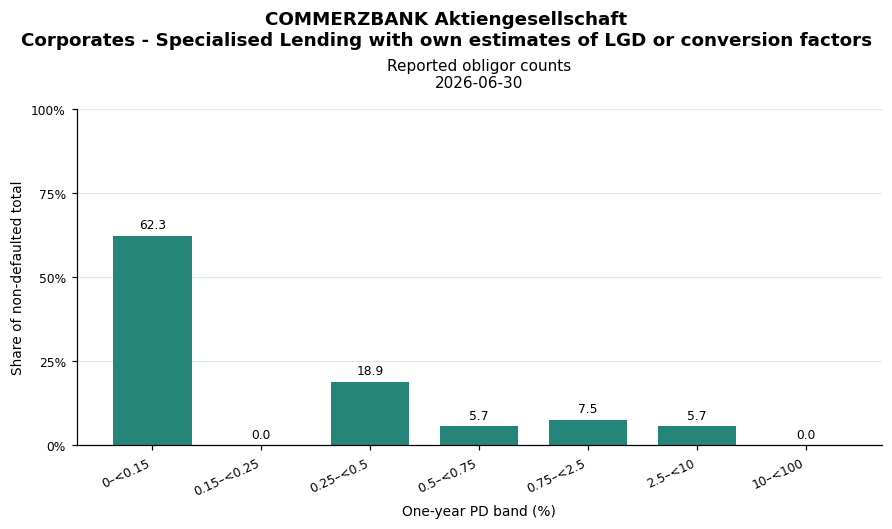

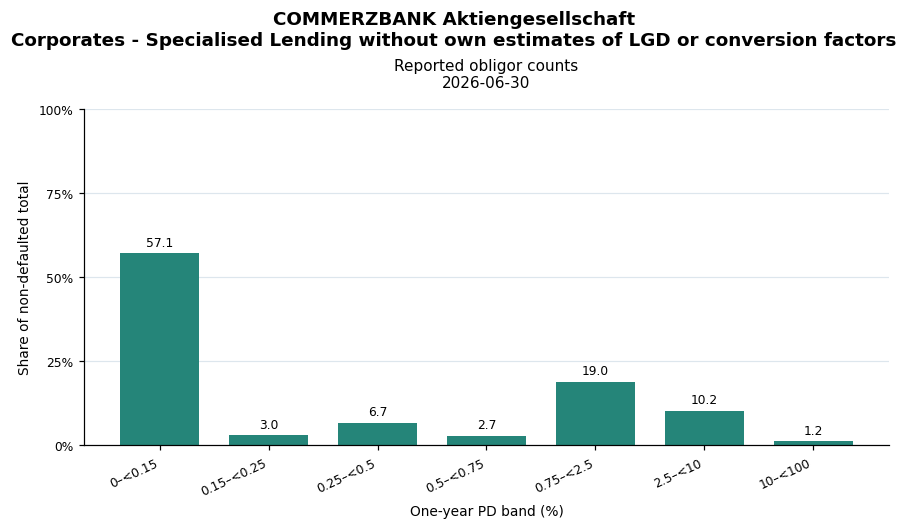

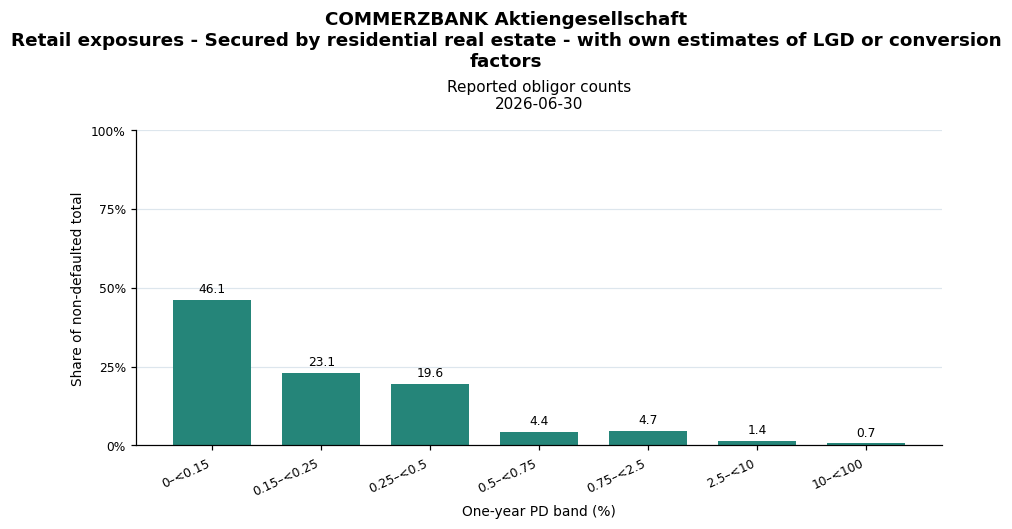

### 3. DZ BANK AG Deutsche Zentral-Genossenschaftsbank, Frankfurt am Main
LEI: 529900HNOAA1KXQJUQ27 · Ranking date: 2026-06-30

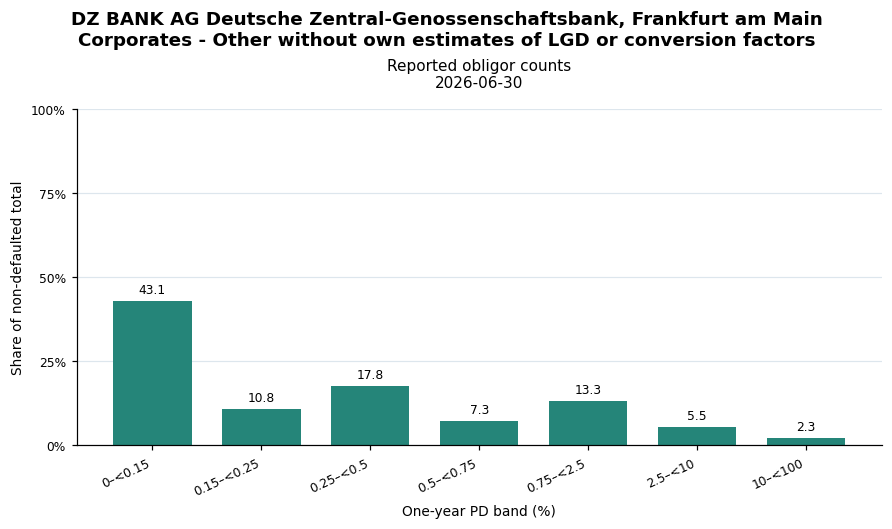

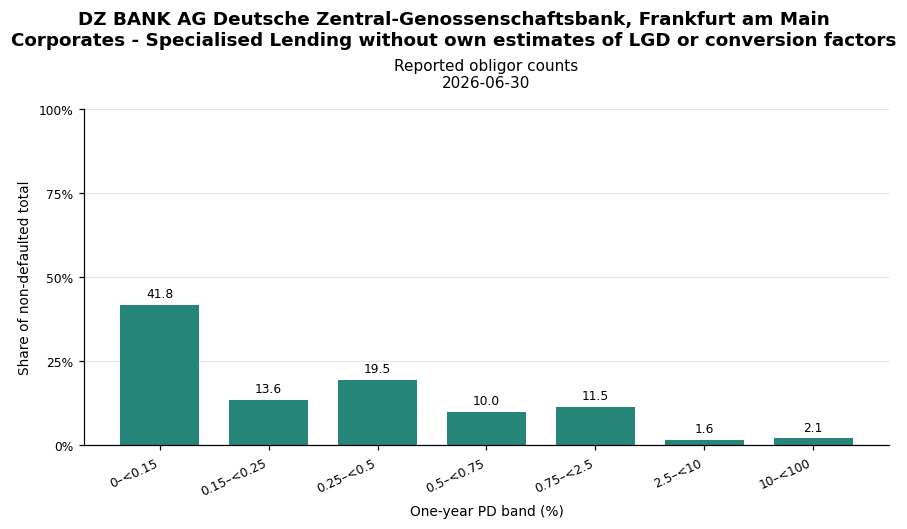

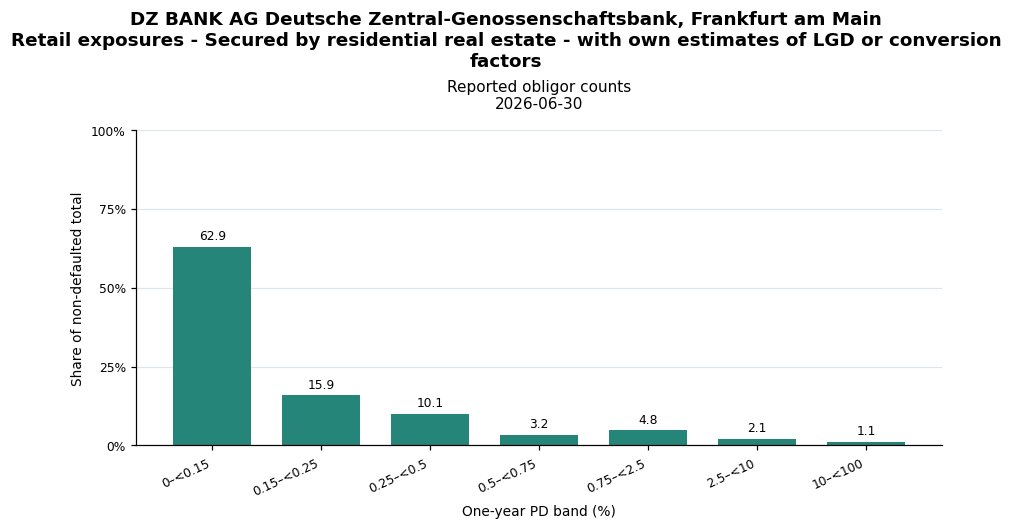

### 4. Bayerische Landesbank
LEI: VDYMYTQGZZ6DU0912C88 · Ranking date: 2026-06-30

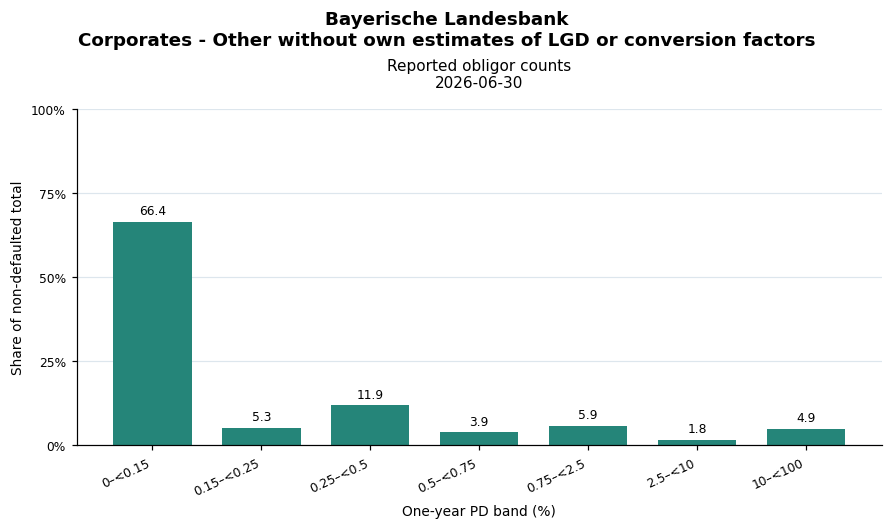

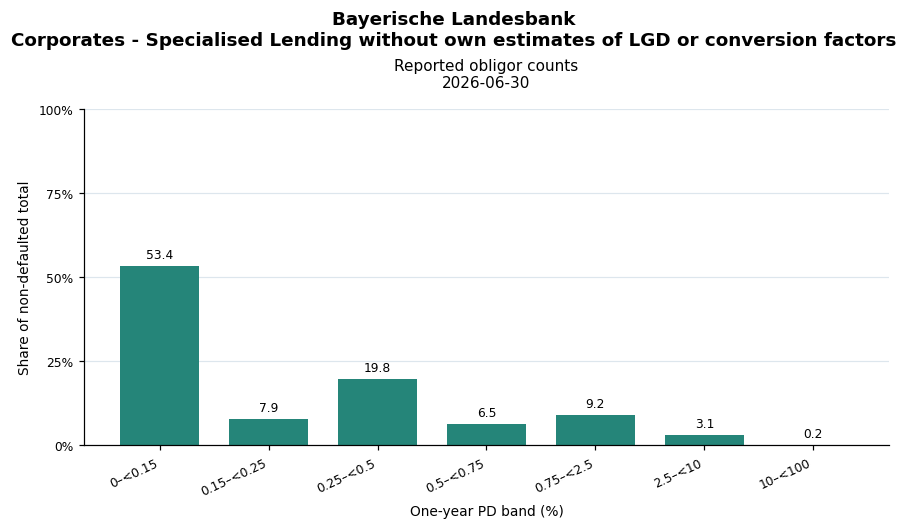

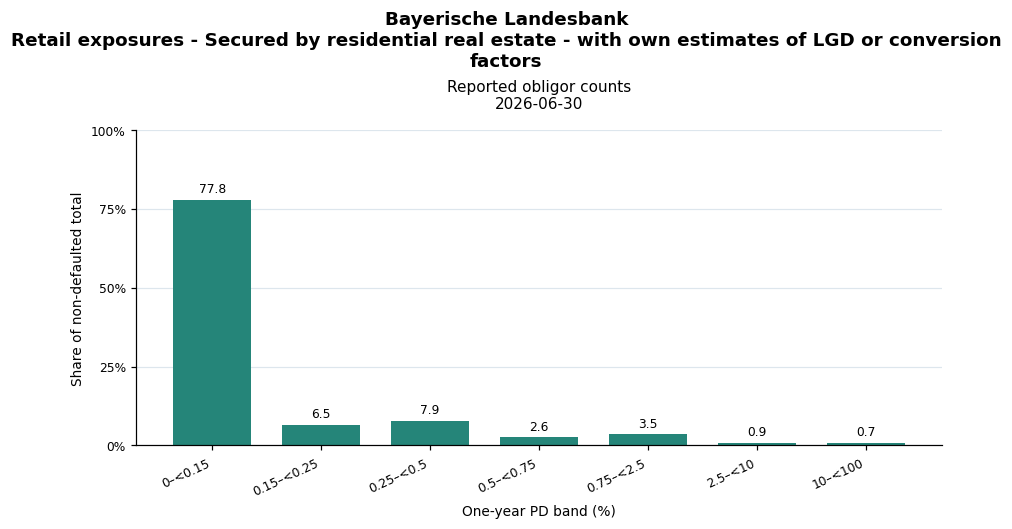

### 5. Landesbank Baden-Württemberg
LEI: B81CK4ESI35472RHJ606 · Ranking date: 2026-06-30

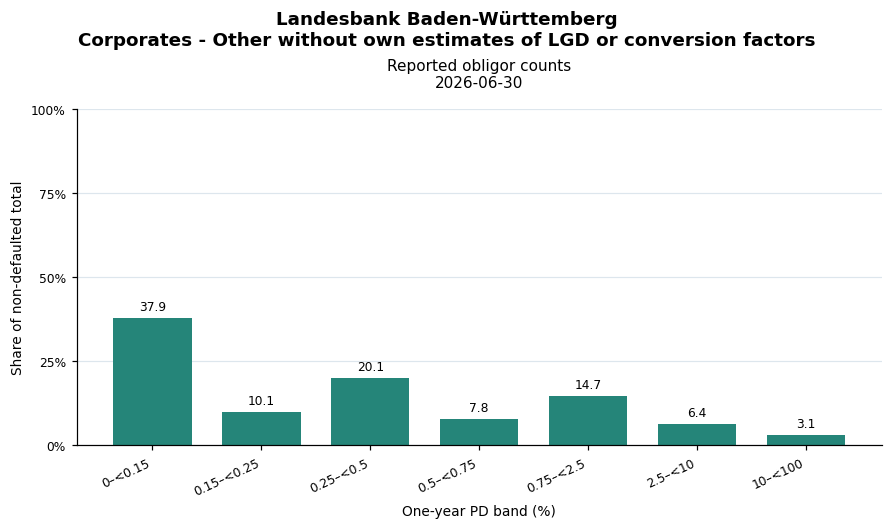

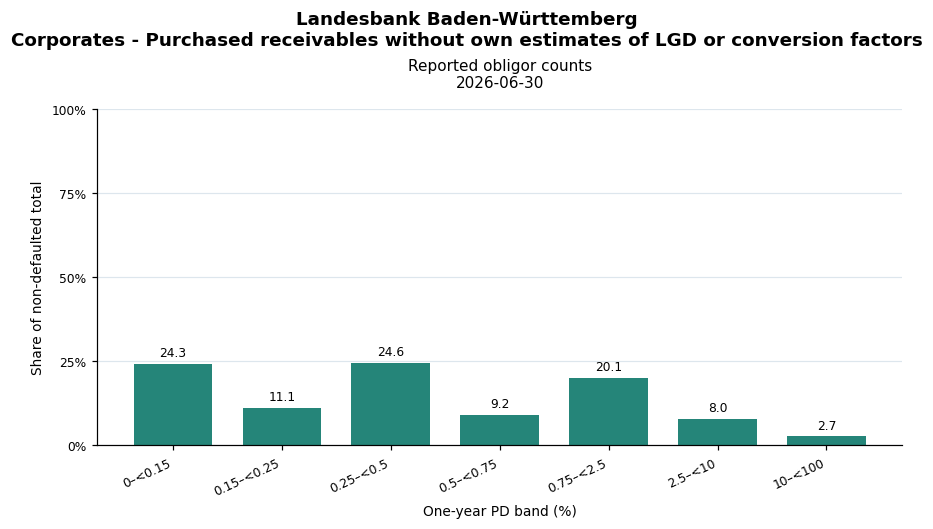

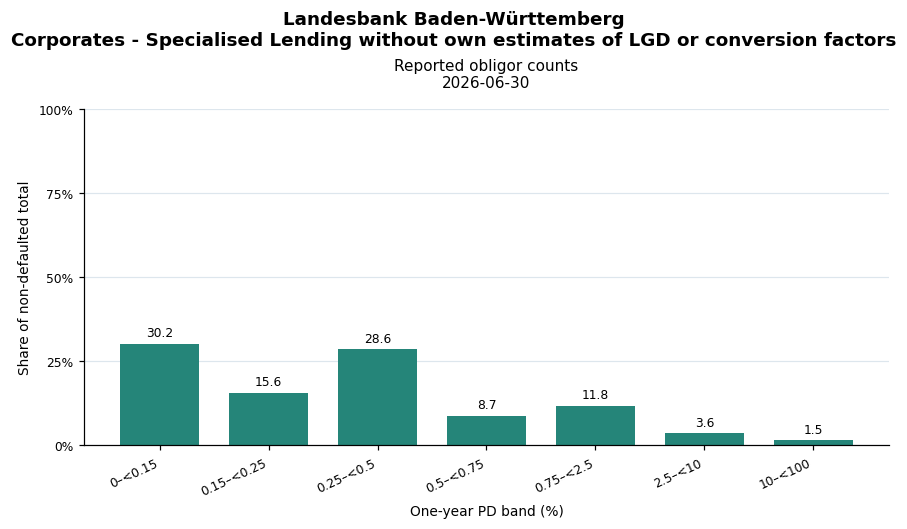

### 6. Landesbank Hessen-Thüringen Girozentrale
LEI: DIZES5CFO5K3I5R58746 · Ranking date: 2026-06-30

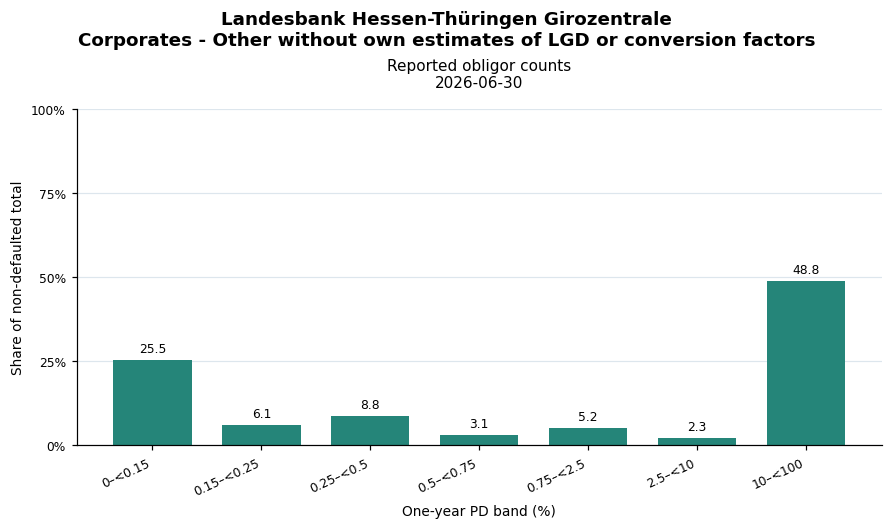

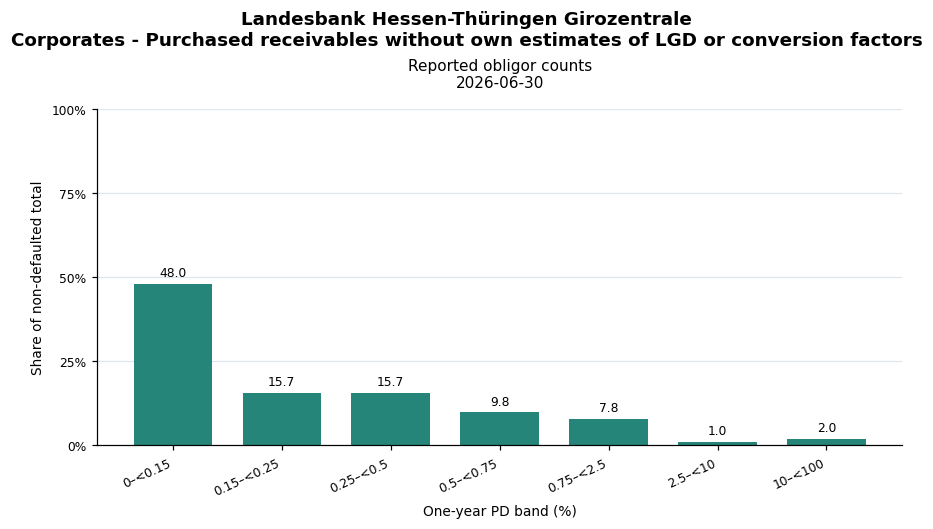

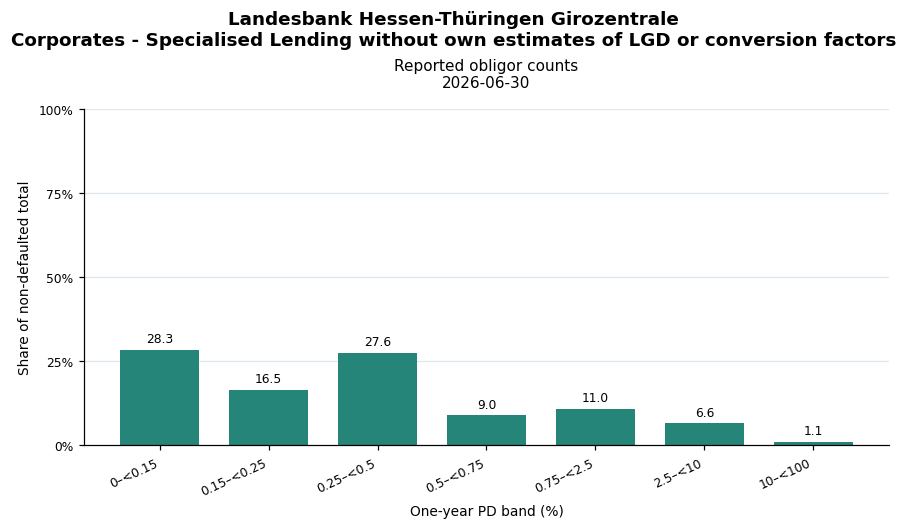

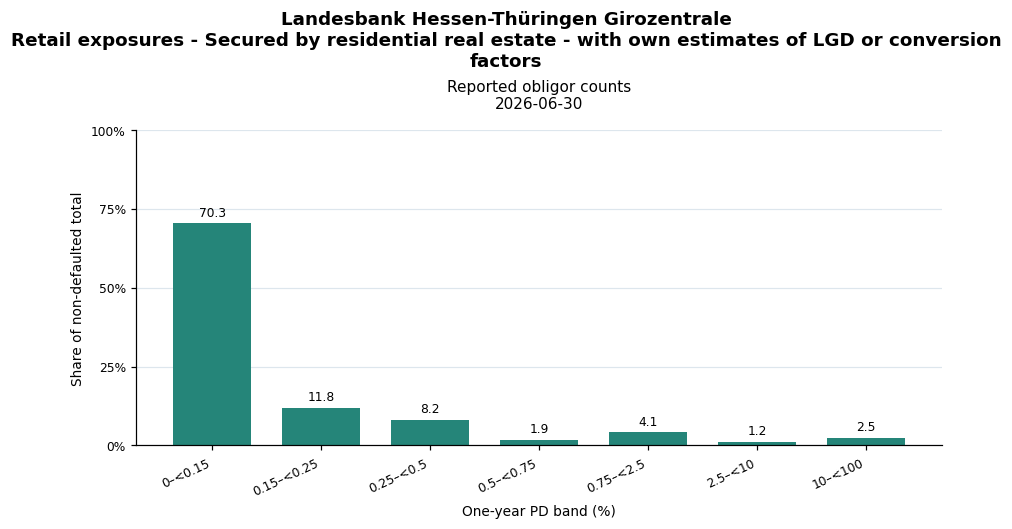

### 7. Norddeutsche Landesbank - Girozentrale -
LEI: DSNHHQ2B9X5N6OUJ1236 · Ranking date: 2026-06-30

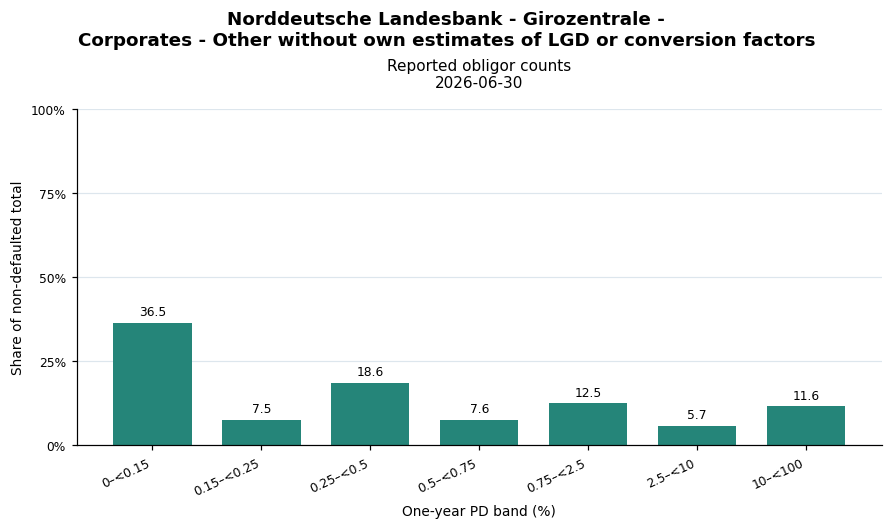

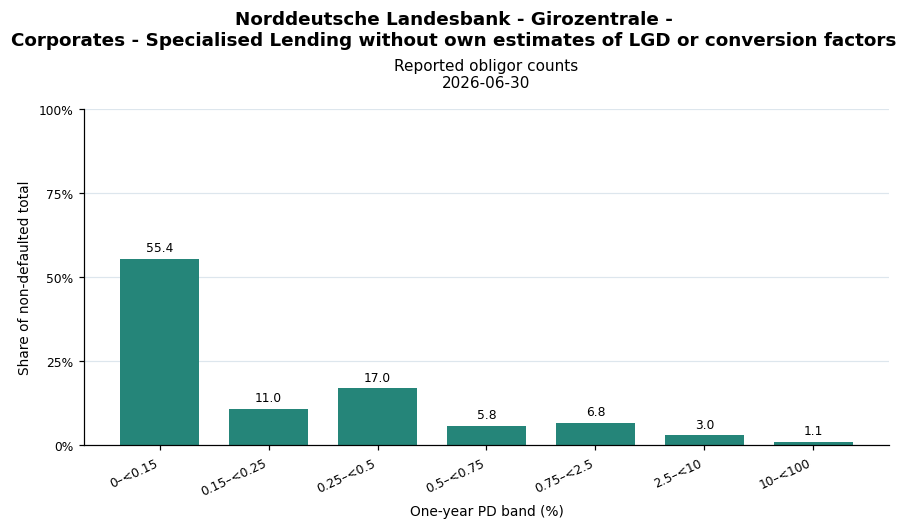

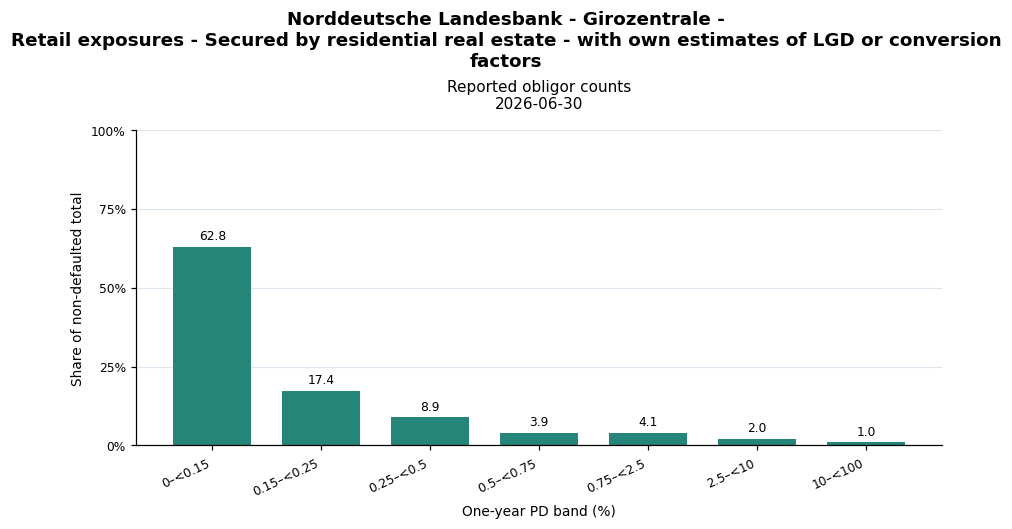

### 10. Aareal Bank AG
LEI: EZKODONU5TYHW4PP1R34 · Ranking date: 2026-06-30

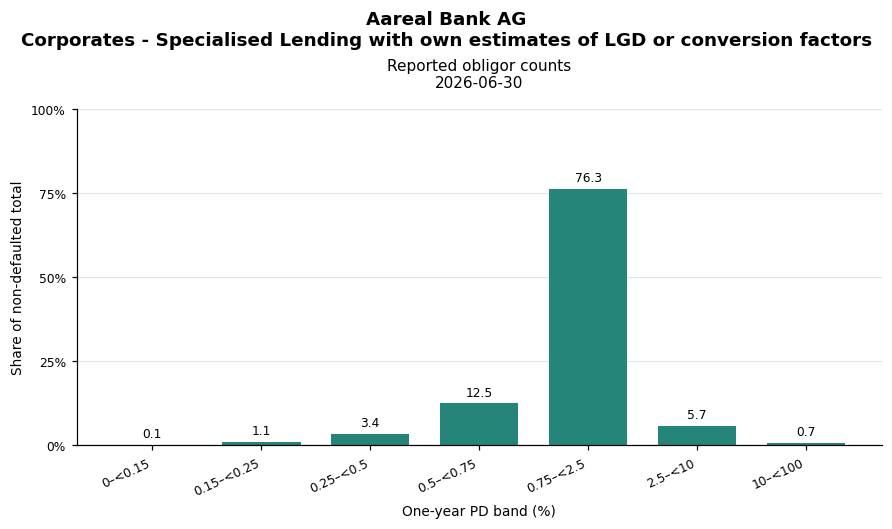

## Denmark — 5 groups

### 1. Danske Bank A/S
LEI: MAES062Z21O4RZ2U7M96 · Ranking date: 2026-06-30

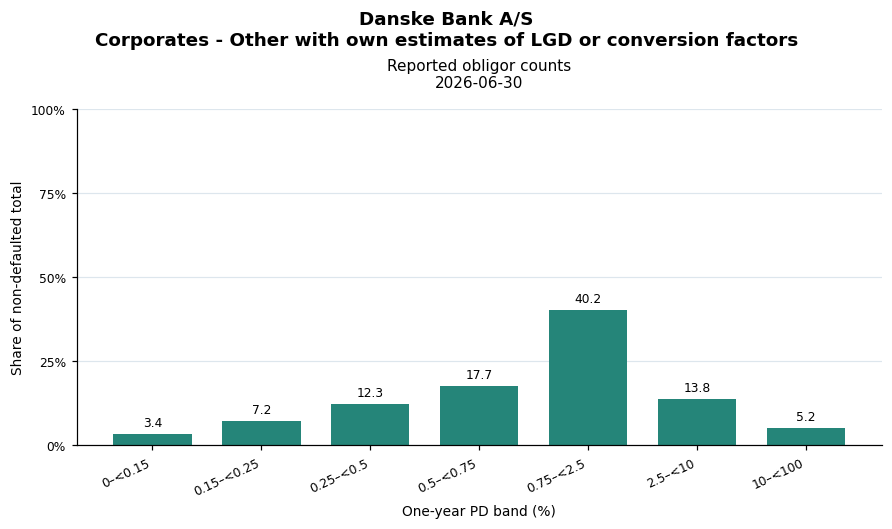

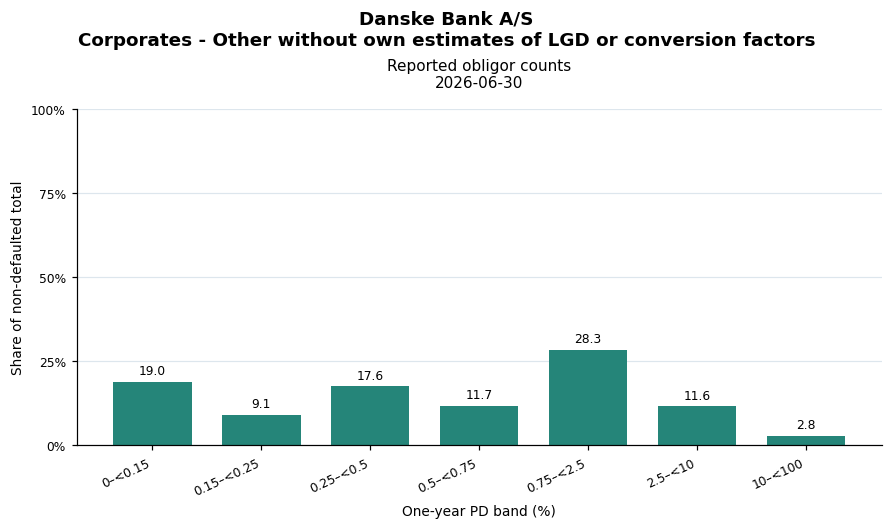

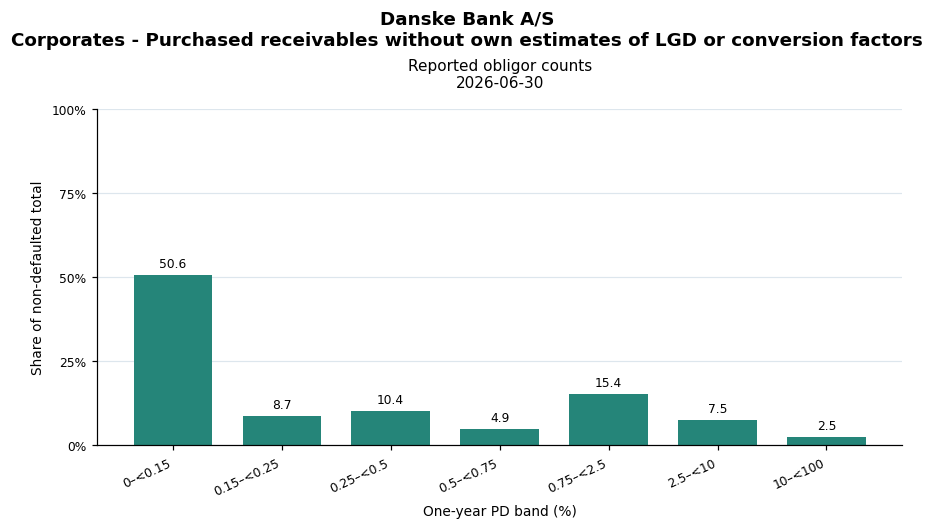

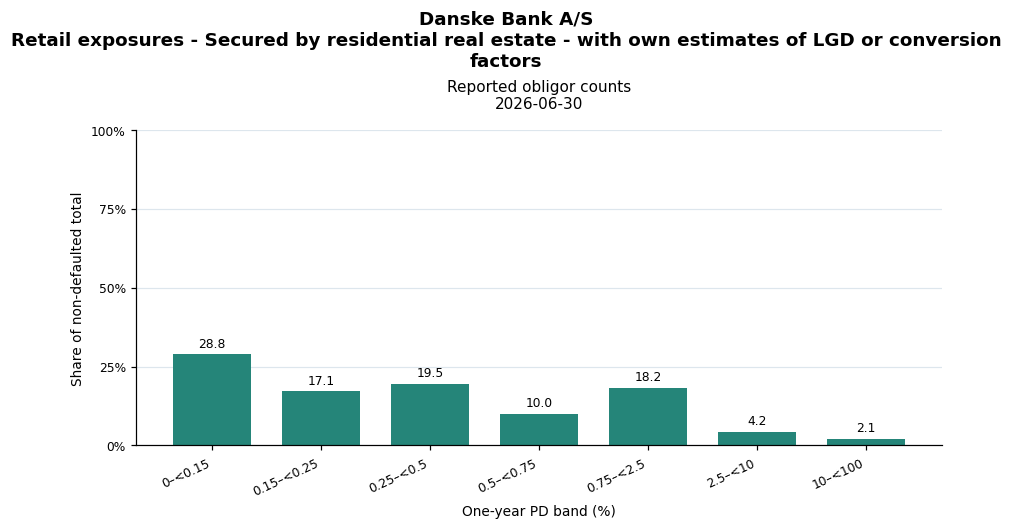

### 2. Jyske Bank A/S
LEI: 3M5E1GQGKL17HI6CPN30 · Ranking date: 2026-06-30

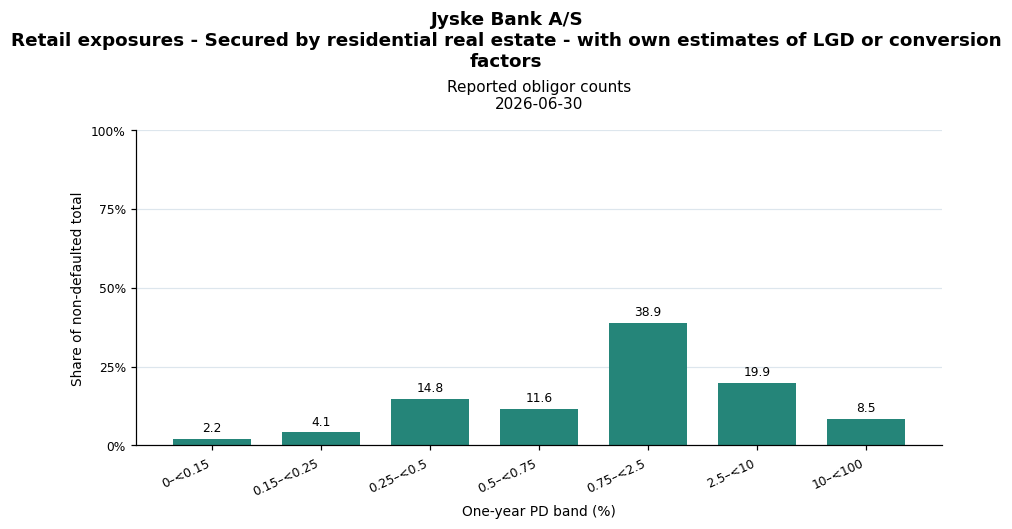

### 3. AL Sydbank A/S
LEI: GP5DT10VX1QRQUKVBK64 · Ranking date: 2026-06-30

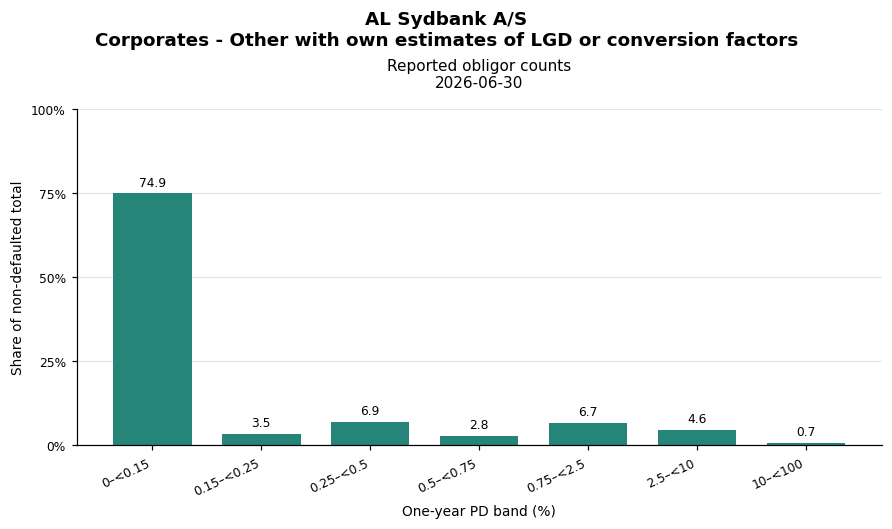

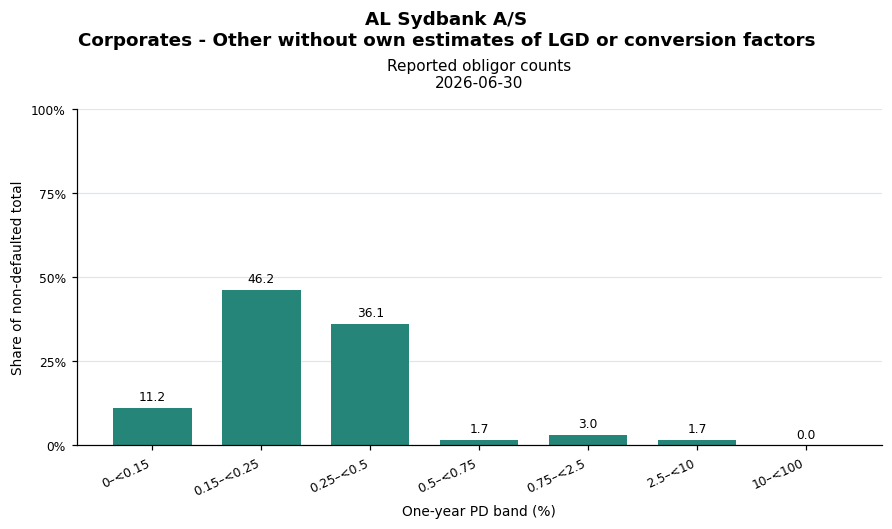

### 5. Nykredit Realkredit A/S
LEI: LIU16F6VZJSD6UKHD557 · Ranking date: 2026-06-30

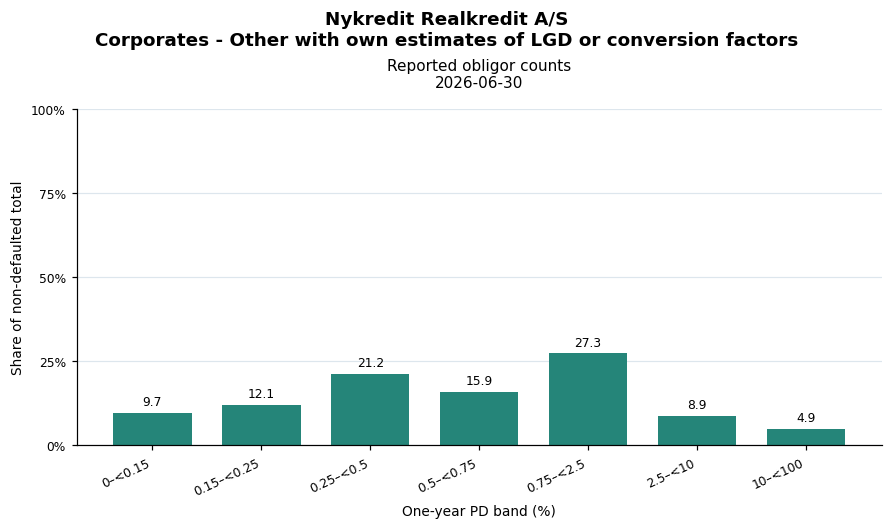

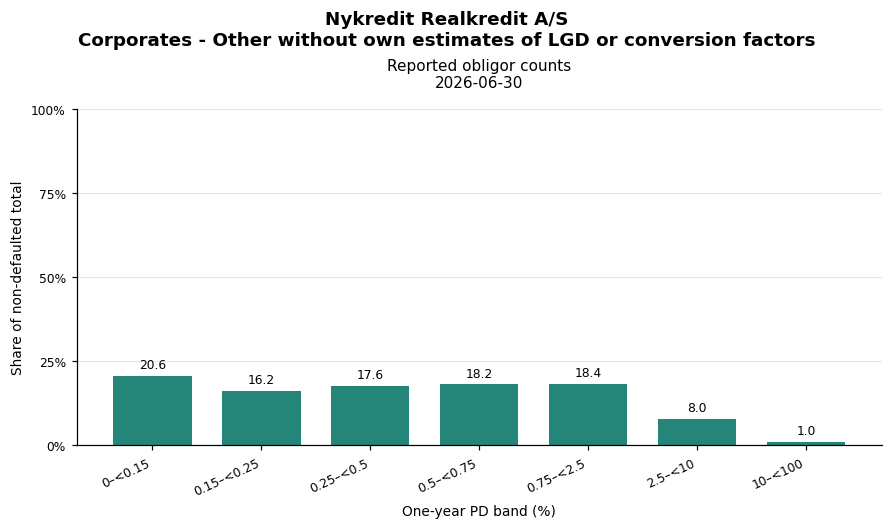

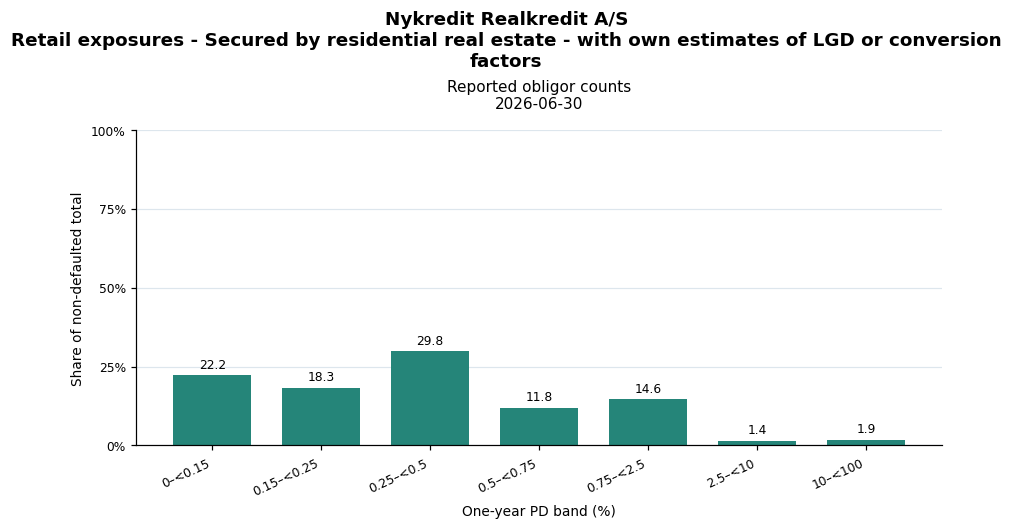

### 6. DLR Kredit A/S
LEI: 529900PR2ELW8QI1B775 · Ranking date: 2026-06-30

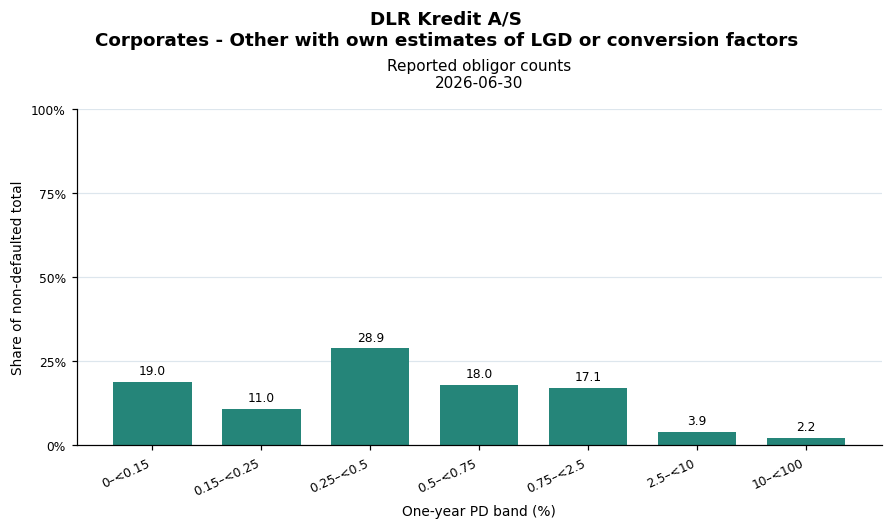

## Sweden — 3 groups

### 1. Skandinaviska Enskilda Banken - gruppen
LEI: F3JS33DEI6XQ4ZBPTN86 · Ranking date: 2026-06-30

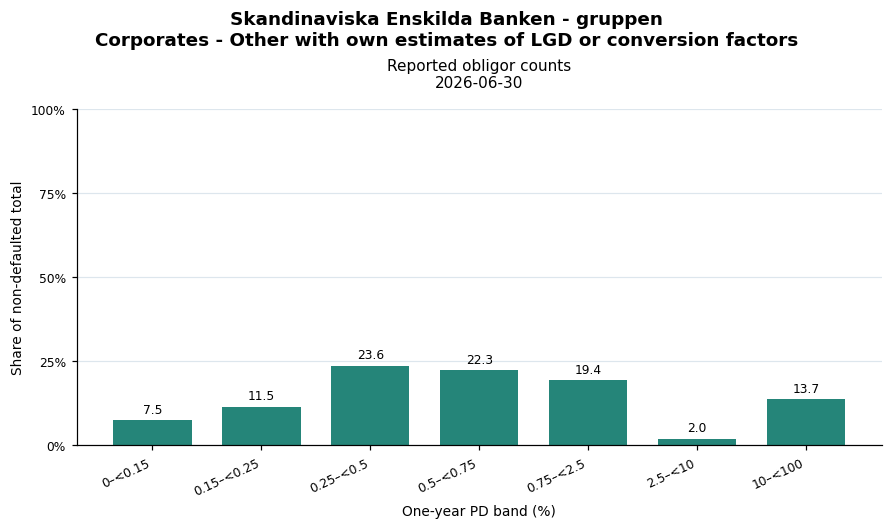

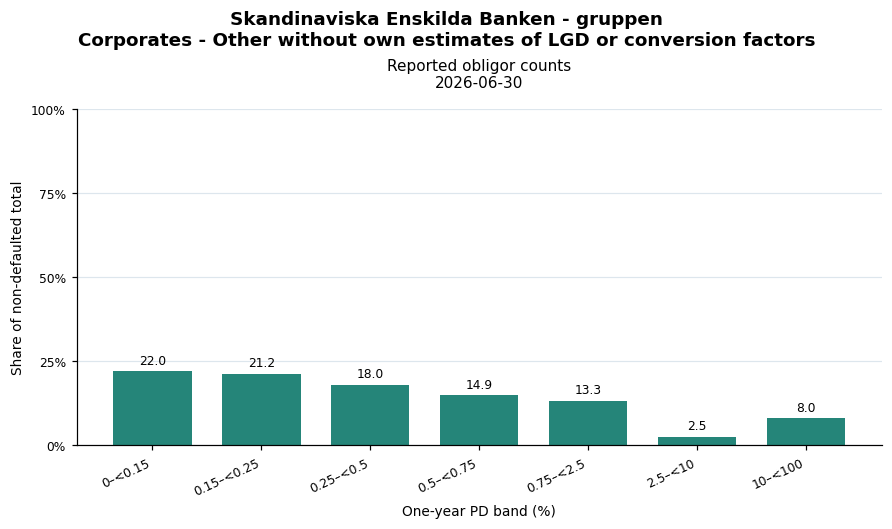

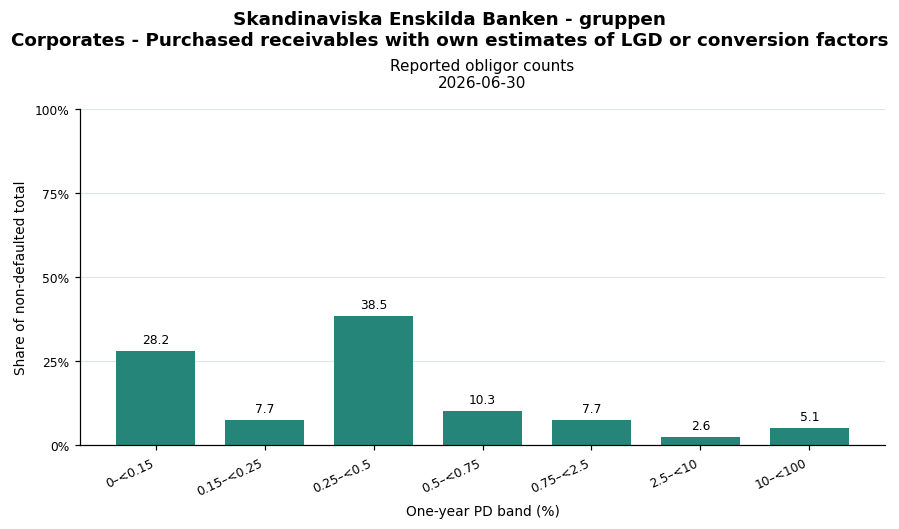

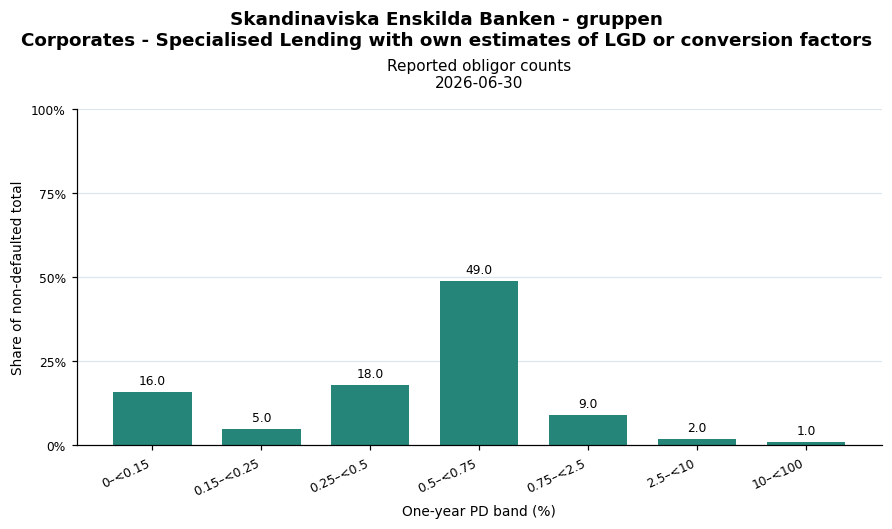

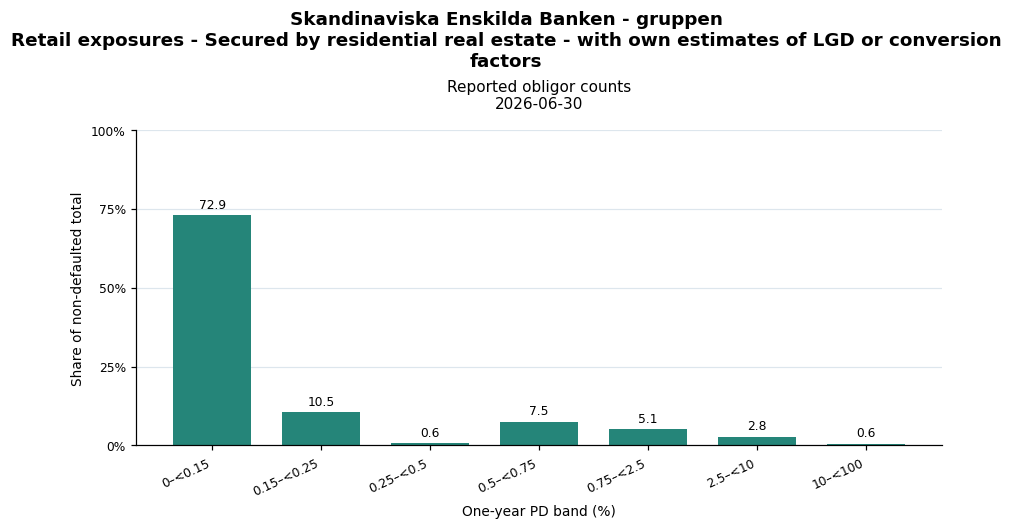

### 3. Swedbank - Grupp
LEI: M312WZV08Y7LYUC71685 · Ranking date: 2026-06-30

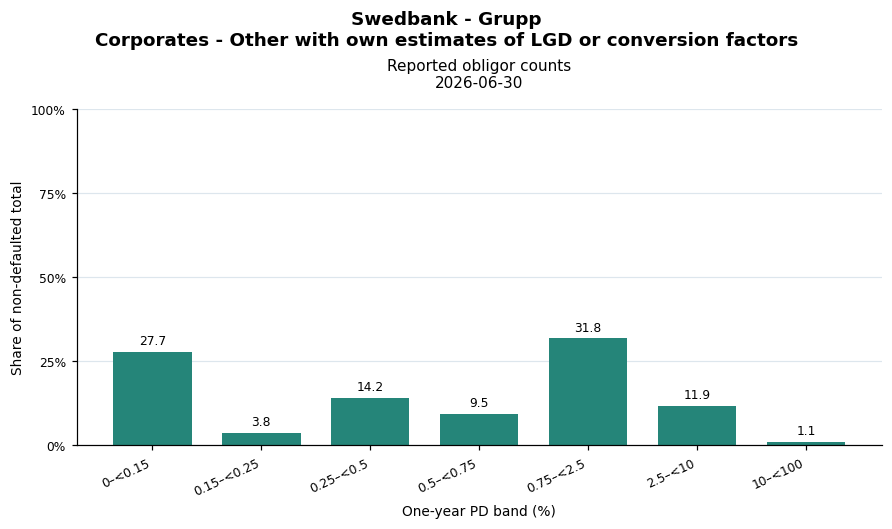

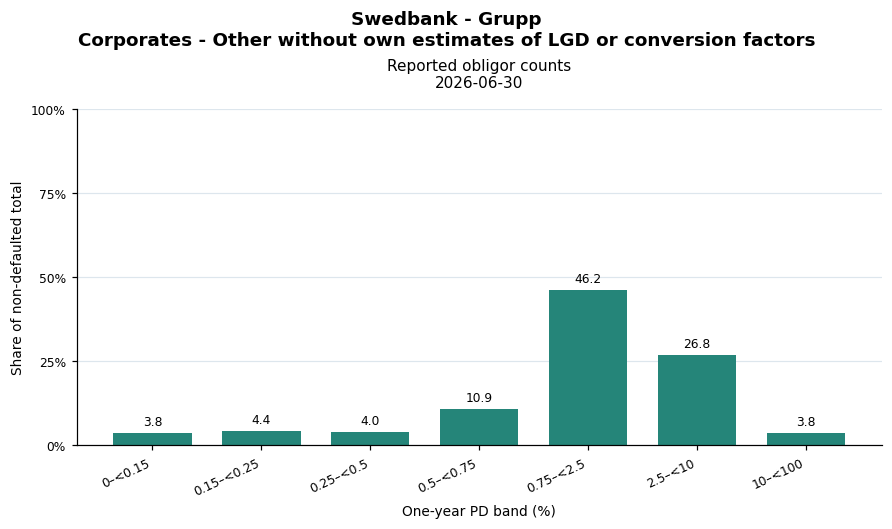

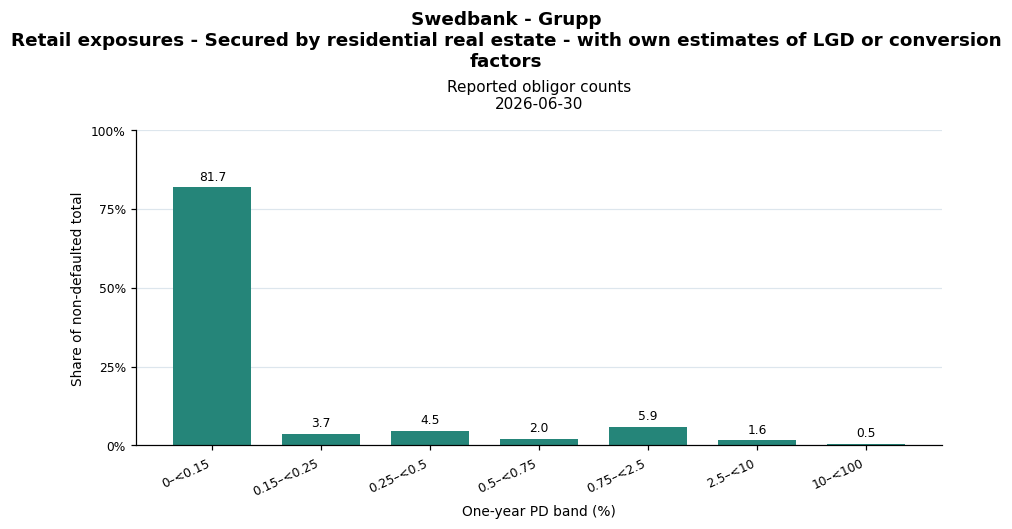

### 4. SBAB Bank AB - Grupp
LEI: H0YX5LBGKDVOWCXBZ594 · Ranking date: 2026-06-30

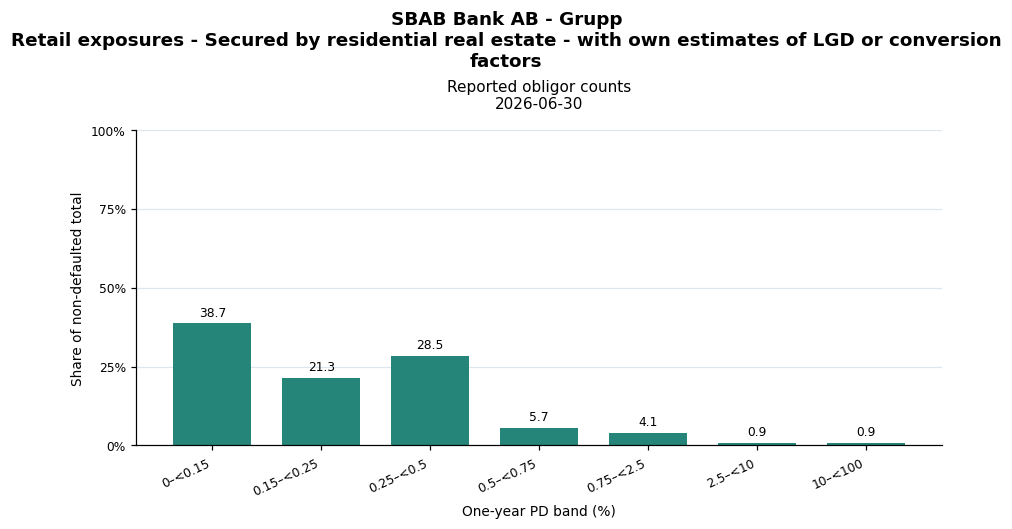

In [4]:
def plot_asset(bank, member, asset_data):
    """Plot available June 2026 obligor-count distributions from embedded values."""
    if asset_data.empty:
        return
    asset_data = asset_data.sort_values(["instance_id", "table_vid", "currency"])
    columns = min(2, len(asset_data))
    rows = (len(asset_data) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(8 if columns == 1 else 13, 3.7 * rows + 1),
                             squeeze=False, layout="constrained")
    fig.suptitle(textwrap.fill(bank.bank.strip(), 95) + "\n" + textwrap.fill(member, 95),
                 fontsize=12, fontweight="bold")
    for ax, record in zip(axes.flat, asset_data.itertuples(index=False)):
        ax.set_title(f"Reported obligor counts\n{record.reference_date}", fontsize=10, pad=14)
        values = np.asarray(record.band_values, dtype=float)
        if len(values) != len(BANDS) or not np.isfinite(values).all() or (values < 0).any() or values.sum() <= 0:
            raise ValueError(f"Invalid chart values for {record.bank}, {record.member}, {record.reference_date}")
        shares = 100 * values / values.sum()
        bars = ax.bar(np.arange(len(BANDS)), shares, color="#258579", width=0.72)
        ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
        ax.set_xticks(np.arange(len(BANDS)), BANDS, rotation=25, ha="right", fontsize=8)
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.yaxis.set_major_formatter(PercentFormatter(100))
        ax.tick_params(axis="y", labelsize=8)
        ax.set_ylabel("Share of non-defaulted total", fontsize=9)
        ax.set_xlabel("One-year PD band (%)", fontsize=9)
        ax.grid(axis="y", color="#dde6ed")
        ax.set_axisbelow(True)
        for side in ["top", "right"]:
            ax.spines[side].set_visible(False)
    for ax in list(axes.flat)[len(asset_data):]:
        ax.set_visible(False)
    plt.show()
    plt.close(fig)


display(Markdown(
    f"**{len(selected)} banking groups · {len(distributions)} obligor-count distributions · June 2026.**"
))
for country in COUNTRIES:
    country_banks = selected.loc[selected.country.eq(country)].sort_values("rank")
    if country_banks.empty:
        continue
    display(Markdown(f"## {country} — {len(country_banks)} groups"))
    for bank in country_banks.itertuples(index=False):
        display(Markdown(f"### {bank.rank}. {bank.bank.strip()}\nLEI: {bank.lei} · Ranking date: {bank.reference_date}"))
        bank_data = distributions.loc[distributions.lei.eq(bank.lei)]
        for member, asset_data in bank_data.groupby("member", sort=True):
            plot_asset(bank, member, asset_data)
